In [1]:
import xarray as xr
import scipy
import numpy as np
import pandas as pd
import copy
from datetime import datetime
import matplotlib.pyplot as plt
import os
import re
from typing import List, Optional
import pandas as pd
import numpy as np
from scipy.sparse import diags
import matplotlib.pyplot as plt
import os
import re
from typing import List, Optional
import numpy as np
import pandas as pd
from typing import Tuple
import torch
from sklearn.linear_model import LinearRegression
import proto_scales.data_prep.prepare_data as prep


In [2]:

def fit_control_mahalanobis(u_train_norm, eps=1e-6):
    """
    u_train_norm: [N, T, Du] standardized using train-only scaler
    Returns mu [Du], inv_cov [Du, Du]
    """
    U = u_train_norm.reshape(-1, u_train_norm.shape[-1])  # [N*T, Du]
    mu = U.mean(axis=0)
    cov = np.cov(U.T) + eps * np.eye(U.shape[1])
    inv_cov = np.linalg.inv(cov)
    return mu.astype(np.float32), inv_cov.astype(np.float32)

def mahalanobis_score(u_fut_norm, mu, inv_cov):
    """
    u_fut_norm: [B, H, Du] standardized
    returns score: [B, H] (per-step)
    """
    diff = u_fut_norm - mu[None, None, :]
    # score[b,h] = diff^T inv_cov diff
    return np.einsum("bhd,dd,bhd->bh", diff, inv_cov, diff)

def pick_threshold_from_val(val_loader, mu, inv_cov, percentile=99.0):
    all_scores = []
    for _, _, u_fut, _ in val_loader:
        #s = mahalanobis_score(u_fut.numpy(), mu, inv_cov)  # [B,H]
        s = mahalanobis_score(u_fut, mu, inv_cov)  # [B,H]
        all_scores.append(s.reshape(-1))
    all_scores = np.concatenate(all_scores)
    return float(np.percentile(all_scores, percentile))


def gate_from_score(score_bh, tau, k=5.0):
    """
    score_bh: torch tensor [B,H]
    returns w: [B,H,1]
    """
    w = torch.sigmoid(k * (tau - score_bh))
    return w.unsqueeze(-1)


In [3]:
@torch.no_grad()
def forecast_with_u_fallback(model, y_ctx, u_ctx, u_fut, mu_u, inv_cov_u, tau, n_samples = 50,k=5.0):
    """
    y_ctx: [B,Tc,Dy] (normalized)
    u_ctx: [B,Tc,Du] (normalized)
    u_fut: [B,H,Du]  (normalized)
    mu_u:  [Du] numpy or torch
    inv_cov_u: [Du,Du] numpy or torch
    """
    device = y_ctx.device
    B, H, Du = u_fut.shape

    # DeepSSM mean forecast (IMPORTANT: mean, no observation noise)
    y_ssm, _, _ = model.forecast(y_ctx, u_ctx, u_fut, steps=H, n_samples=n_samples)  # [B,H,Dy]
    # If your forecast adds obs noise, remove it for MSE evaluation.

    # Linear fallback
    y_lin = model.ctrl_lin(u_fut.reshape(-1, Du)).reshape(B, H, -1)

    # Control OOD score (Mahalanobis)
    mu_u_t = torch.as_tensor(mu_u, device=device)
    inv_t  = torch.as_tensor(inv_cov_u, device=device)

    diff = u_fut - mu_u_t[None, None, :]
    score = torch.einsum("bhd,dd,bhd->bh", diff, inv_t, diff)  # [B,H]

    # Gate + blend
    w = gate_from_score(score, tau=tau, k=k)  # [B,H,1]
    y_mix = w * y_ssm + (1.0 - w) * y_lin

    return y_mix, y_ssm, y_lin, score, w


Data prep:

In [ ]:
import warnings
#warnings.filterwarnings("ignore")

MODEL = 'ACCESS-ESM1-5'
INDICATOR = 'tas'#'pr' #'tas'
TEST_SCENARIOS = ['abrupt-4xco2']
#TRAIN_SCENARIOS = ['ssp585','1pctco2','ssp245'] # for "pr"
monthly_flag = False
use_smoothing = True
TRAIN_SCENARIOS = ['ssp534-over','flat10cdrincspinoff','ssp585','1pctco2','ssp245']#,'ssp126','flat10zecincspinoff']#, 'flat10cdrincspinoff','abrupt-4xco2','ssp119','ssp460','ssp370']
N = 200
ML_MODEL = 'feed_forward'
PATTERN_SCALING_RESIDUALS = False
RAMP_DOWN_CORRECTED_PS = False
train_pattern_scaling_name = 'flat10cdrincspinoff'#'ssp585'#'flat10cdrincspinoff'

MODEL_PATH = f'/projects/icigroup/CMIP6/cmip6-ng-inc-oceans/{MODEL}'



with warnings.catch_warnings():
   warnings.simplefilter("ignore")
   

    potential_files = prep.get_all_files_(MODEL_PATH)
    
    train_files = prep.filter_climate_files(files = potential_files, scenarios = TRAIN_SCENARIOS, indicators = [INDICATOR])
    test_files = prep.filter_climate_files(files = potential_files, scenarios = TEST_SCENARIOS, indicators = [INDICATOR])
        
    train_files_with_baseline = [(prep.get_baseline_filename(filename=filename, files= potential_files), filename) for filename in train_files]
    test_files_with_baseline = [(prep.get_baseline_filename(filename=filename, files= potential_files), filename) for filename in test_files]
    
    for (base,exp) in test_files_with_baseline: 
        print(base, exp)
    
    train_data_df = [prep.process_scenarios(experiment_scenario_path = f'{MODEL_PATH}/{experiment}', simulation_name = experiment, baseline_scenario_path = f'{MODEL_PATH}/{baseline}', delete_first_years = 0, monthly_trend = monthly_flag, smoothed = use_smoothing) for (baseline,experiment) in train_files_with_baseline]
    test_data_df = [prep.process_scenarios(experiment_scenario_path = f'{MODEL_PATH}/{experiment}', simulation_name = experiment, baseline_scenario_path = f'{MODEL_PATH}/{baseline}', delete_first_years = 0, monthly_trend = monthly_flag, smoothed = use_smoothing) for (baseline,experiment) in test_files_with_baseline]
    
    train_data_df = [prep.process_scenarios(experiment_scenario_path = f'{MODEL_PATH}/{experiment}', simulation_name = experiment, baseline_scenario_path = f'{MODEL_PATH}/{baseline}', delete_first_years = 0, monthly_trend = monthly_flag, smoothed = use_smoothing) for (baseline,experiment) in train_files_with_baseline]
    test_data_df = [prep.process_scenarios(experiment_scenario_path = f'{MODEL_PATH}/{experiment}', simulation_name = experiment, baseline_scenario_path = f'{MODEL_PATH}/{baseline}', delete_first_years = 0, monthly_trend = monthly_flag, smoothed = use_smoothing) for (baseline,experiment) in test_files_with_baseline]
    
    if PATTERN_SCALING_RESIDUALS:
        flat10cdr_index = [i for i, f in enumerate(train_files) if train_pattern_scaling_name in f][0]
        regional_regression_slopes_intersepts = prep.process_gmt_and_regions_into_array(train_data_df[flat10cdr_index], weighted_linear_smoothing = False, pattern_scaling_residuals=PATTERN_SCALING_RESIDUALS)
        train_data_np = [prep.process_gmt_and_regions_into_array(GMT_regional_values_tuple, weighted_linear_smoothing = False, pattern_scaling_residuals=PATTERN_SCALING_RESIDUALS, slope_intercept = regional_regression_slopes_intersepts,ramp_down_corrected_ps = RAMP_DOWN_CORRECTED_PS) for GMT_regional_values_tuple in train_data_df]
        test_data_np = [prep.process_gmt_and_regions_into_array(GMT_regional_values_tuple, weighted_linear_smoothing = False, pattern_scaling_residuals=PATTERN_SCALING_RESIDUALS, slope_intercept = regional_regression_slopes_intersepts, ramp_down_corrected_ps = RAMP_DOWN_CORRECTED_PS) for GMT_regional_values_tuple in test_data_df]
    else:
        flat10cdr_index = [i for i, f in enumerate(train_files) if train_pattern_scaling_name in f][0]
        regional_regression_slopes_intersepts = prep.process_gmt_and_regions_into_array(train_data_df[flat10cdr_index], weighted_linear_smoothing = False, pattern_scaling_residuals=True,ramp_down_corrected_ps = RAMP_DOWN_CORRECTED_PS)
        train_data_np = [prep.process_gmt_and_regions_into_array(GMT_regional_values_tuple, weighted_linear_smoothing = False,ramp_down_corrected_ps = RAMP_DOWN_CORRECTED_PS) for GMT_regional_values_tuple in train_data_df]
        test_data_np = [prep.process_gmt_and_regions_into_array(GMT_regional_values_tuple, weighted_linear_smoothing = False, ramp_down_corrected_ps = RAMP_DOWN_CORRECTED_PS) for GMT_regional_values_tuple in test_data_df]
    
    train_data_input, train_data_output = prep.prepare_all_train_data(train_data_np, n=N)
    test_data_input, test_data_output = prep.prepare_all_train_data(test_data_np, n=N)
    
    train_data_shuffeled = prep.shuffle_train_data(train_data_input, train_data_output, random_state=42)
    
    test_data_for_autoregression_input, test_data_for_autoregression_output = prep.prepare_train_data(test_data_np[0],N)
    
    gmt_autoregressive_test = test_data_np[0][0,:]
    autoregressive_test_groudtruth = test_data_np[0][1:,:]
    
    gmt_train = train_data_np[0][0,:]
    train_data_regional_temperature = train_data_np[0][1:,:]

In [28]:
import pickle
pickle_filename = "/hdrive/all_users/kainverena/formatted_data/input_data_flat10cdr.pkl"
N = 200

with open(pickle_filename, 'rb') as f:

    train_data_input = pickle.load(f) # deserialize using load()
    train_data_output = pickle.load(f)
    #test_data_input = pickle.load(f) # deserialize using load()
    #test_data_output = pickle.load(f)
    #test_data_np = pickle.load(f)
    test_data_for_autoregression_input = pickle.load(f)
f.close()

train_data_shuffeled = prep.shuffle_train_data(train_data_input, train_data_output, random_state=42)
    
#test_data_for_autoregression_input, test_data_for_autoregression_output = prep.prepare_train_data(test_data_np[0],N)

#gmt_autoregressive_test = test_data_np[0][0,:]
#autoregressive_test_groudtruth = test_data_np[0][1:,:]

#gmt_train = train_data_np[0][0,:]
#train_data_regional_temperature = train_data_np[0][1:,:]

(5211, 200, 1)


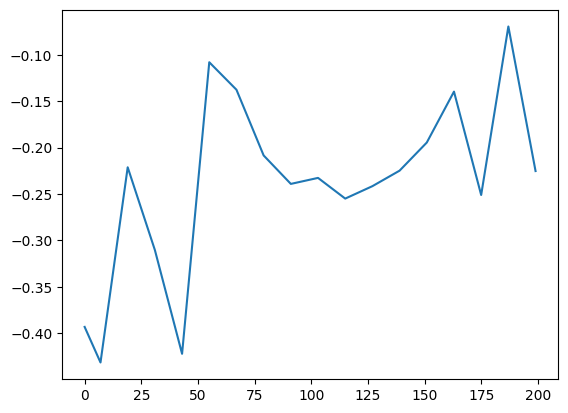

In [5]:
#print(test_data_np[0].shape)
u = test_data_for_autoregression_input[0,:].T[..., None]
#y = np.transpose(test_data_for_autoregression_input[44:48,:],(2, 1, 0))
y = np.transpose(test_data_for_autoregression_input[:,:],(2, 1, 0))

print(u.shape)
plt.plot(u[1000,:,0])

(10421, 200, 59)
(10421, 200, 1)
8026
35


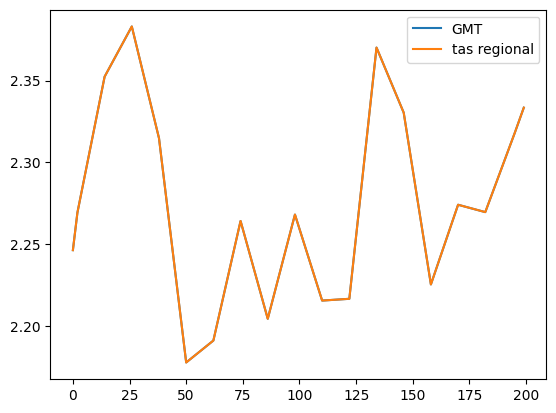

In [6]:
u = train_data_shuffeled[0][0,:].T[..., None]
#y = np.transpose(train_data_shuffeled[0][44:48,:],(2, 1, 0))
y = np.transpose(train_data_shuffeled[0][:,:],(2, 1, 0))
print(y.shape)
print(u.shape)
choose_slice = np.random.randint(len(y))
print(choose_slice)
choose_region = np.random.randint(len(y[0,0,:]))
print(choose_region)
choose_region = 0

plt.plot(u[choose_slice,:,0],label="GMT")
plt.plot(y[choose_slice,:,choose_region],label="tas regional")
plt.legend()


SSM Model definition 

In [29]:
from proto_scales.ssm_model.scales_ssm import StandardScaler

u = train_data_shuffeled[0][0,:].T[..., None]
#y = np.transpose(train_data_shuffeled[0][44:48,:],(2, 1, 0))
y = np.transpose(train_data_shuffeled[0][:,:],(2, 1, 0))
print(np.min(u),np.max(u))
print(np.min(y),np.max(y))

N = y.shape[0]
idx = np.random.permutation(N)
n_train = int(0.8 * N)
tr_idx, va_idx = idx[:n_train], idx[n_train:]

y_tr, u_tr = y[tr_idx], u[tr_idx]
y_va, u_va = y[va_idx], u[va_idx]

# normalize (fit on train only)
y_scaler = StandardScaler().fit(y_tr)
u_scaler = StandardScaler().fit(u_tr)
device = "cuda"

#model, y_scaler, u_scaler = run_train(y, u, context_len=50, horizon=25, device=device,epochs=10)


-0.2966323285898132 2.8730353119609853
-27.062430189775768 25.430989115402895


In [30]:
from proto_scales.ssm_model.scales_ssm import UnifiedWindowDataset
import proto_scales.ssm_model.scales_ssm as scales_ssm

mu_control, inv_cov_control = fit_control_mahalanobis(u_scaler.transform(u_tr))
y_van = y_scaler.transform(y_va)
u_van = u_scaler.transform(u_va)
val_ds   = scales_ssm.UnifiedWindowDataset(y_van, u_van, context_len=50, horizon=150,standard_scaler_u=u_scaler,standard_scaler_y=y_scaler)

tau_ood = pick_threshold_from_val(val_ds,mu_control,inv_cov_control)






-0.21724927234897962 2.5377432168347602
(5810, 200, 59) 1
(10, 50)


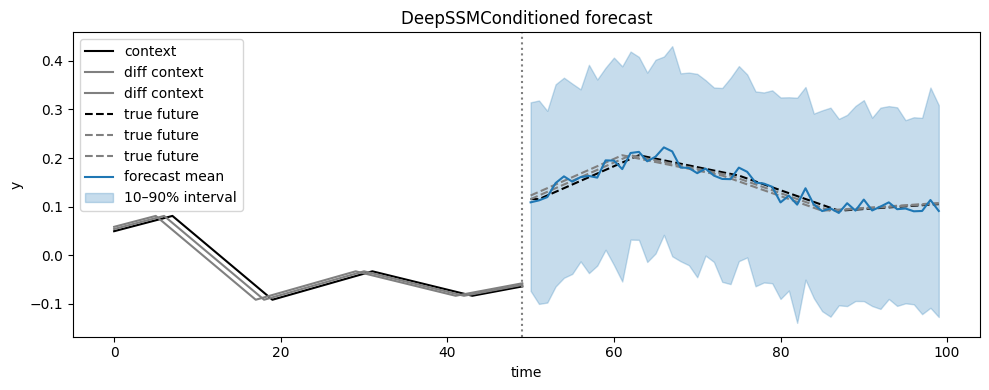

In [32]:
from proto_scales.ssm_model.scales_ssm import DeepSSMConditioned
from proto_scales.ssm_model.scales_ssm_ridge import DeepSSMPatternConditioned
import torch

#print(test_data_np[0].shape)
u = test_data_for_autoregression_input[0,:].T[..., None]
#y = np.transpose(test_data_for_autoregression_input[44:48,:],(2, 1, 0))
y = np.transpose(test_data_for_autoregression_input[:,:],(2, 1, 0))

print(np.min(u),np.max(u))

model_filename = "/home/kainverena/PythonProjects/outputs_ssm_scales/training_11Feb26/model_out"

device = "cuda"
Dy = y.shape[-1]
Du = u.shape[-1]

print(y.shape,Du)


model = DeepSSMPatternConditioned(y_dim=Dy, u_dim=Du, z_dim=24).to(device)
model.load_state_dict(torch.load(model_filename, map_location=torch.device(device)))

model.eval()





# Normalize using training scalers
y_n = y_scaler.transform(y)
u_n = u_scaler.transform(u)

Tc = 50
H = 50

# y_ctx = torch.tensor(y_n[:, :Tc], dtype=torch.float32)
# u_ctx = torch.tensor(u_n[:, :Tc], dtype=torch.float32)
# u_fut = torch.tensor(u_n[:, Tc:Tc+H], dtype=torch.float32)
# y_true = y[:, Tc:Tc+H, 0]   # unnormalized true future

y_ctx = torch.tensor(y_n[-10:,-(Tc+H):-H], dtype=torch.float32, device=device)
u_ctx = torch.tensor(u_n[-10:,-(Tc+H):-H], dtype=torch.float32,device=device)
u_fut = torch.tensor(u_n[-10:, -H:], dtype=torch.float32,device=device)
y_true = y[-10:,-H:, 0]   # unnormalized true future

print(y_true.shape)
with torch.no_grad():
    mean_n, p10_n, p90_n = model.forecast(
        y_ctx, u_ctx, u_fut,
        steps=H,
        n_samples=200,
    )

# Inverse transform predictions
mean = y_scaler.inverse_transform(mean_n.cpu().numpy())[:, :, 0]
p10  = y_scaler.inverse_transform(p10_n.cpu().numpy())[:, :, 0]
p90  = y_scaler.inverse_transform(p90_n.cpu().numpy())[:, :, 0]

# Build time axis
t_ctx = np.arange(Tc)
t_fut = np.arange(Tc, Tc + H)

# Plot
plt.figure(figsize=(10, 4))
#plt.plot(t_ctx, y[0, :Tc, 0], label="context", color="black")
plt.plot(t_ctx, y[0,-(Tc+H):-H, 0], label="context", color="black")
plt.plot(t_ctx, y[1,-(Tc+H):-H, 0], label="diff context", color="grey")
plt.plot(t_ctx, y[2,-(Tc+H):-H, 0], label="diff context", color="grey")
plt.plot(t_fut, y_true[0], label="true future", color="black", linestyle="--")
plt.plot(t_fut, y_true[1], label="true future", color="grey", linestyle="--")
plt.plot(t_fut, y_true[2], label="true future", color="grey", linestyle="--")

plt.plot(t_fut, mean[0], label="forecast mean", color="tab:blue")
plt.fill_between(
    t_fut,
    p10[0],
    p90[0],
    color="tab:blue",
    alpha=0.25,
    label="10–90% interval",
)

plt.axvline(Tc - 1, color="gray", linestyle=":")
plt.legend()
plt.title("DeepSSMConditioned forecast")
plt.xlabel("time")
plt.ylabel("y")
plt.tight_layout()
#plt.show()

In [23]:
#os.makedirs("/home/kainverena/PythonProjects/outputs_ssm_scales", exist_ok=True)
#torch.save(model.state_dict(),"/home/kainverena/PythonProjects/outputs_ssm_scales/model_special")

(5811, 200, 1)
(5811, 200, 59)
(200, 59)


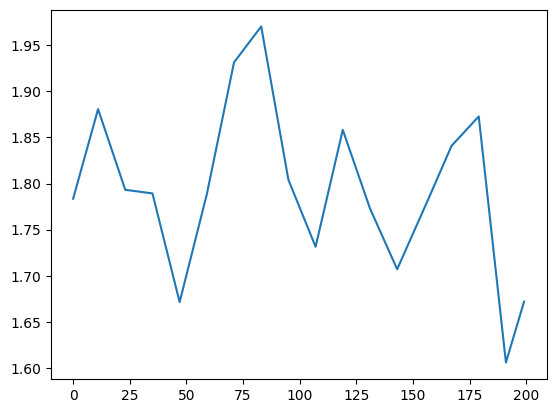

In [9]:
import proto_scales.data_prep.prepare_data as prep

test_index =0
print(u.shape)
print(y.shape)

u_t = train_data_shuffeled[0][0,:].T[..., None]
#y = np.transpose(train_data_shuffeled[0][44:48,:],(2, 1, 0))
y_t = np.transpose(train_data_shuffeled[0][:,:],(2, 1, 0))

bla = prep.fit_regional_regressions(
    u_t[150,:],
    y_t[150,:],
    train_ramp_down=False,
)

prediction = prep.predict_regional_temperatures(
    u[test_index,:],
    bla['slopes_up'],
    bla['intercepts_up'],
    slopes_down=None,
    intercepts_down=None,
    same_shape=False,
)

print(prediction.shape)
plt.plot(prediction[:,1])

In [33]:
u = test_data_for_autoregression_input[0,:].T[..., None]
#y = np.transpose(test_data_for_autoregression_input[44:48,:],(2, 1, 0))
y = np.transpose(test_data_for_autoregression_input,(2, 1, 0))


# Normalize using training scalers
y_n = y_scaler.transform(y)
u_n = u_scaler.transform(u)
print("How much data ",len(y),y.shape,u.shape)
offset = 300
extra_test_index = 1
assert extra_test_index < offset
test_index = len(y)-offset+extra_test_index 

Tc = 50
H = 150

# y_ctx = torch.tensor(y_n[:, :Tc], dtype=torch.float32)
# u_ctx = torch.tensor(u_n[:, :Tc], dtype=torch.float32)
# u_fut = torch.tensor(u_n[:, Tc:Tc+H], dtype=torch.float32)
# y_true = y[:, Tc:Tc+H, 0]   # unnormalized true future

y_ctx = torch.tensor(y_n[-offset:,-(Tc+H):-H], dtype=torch.float32, device=device)
u_ctx = torch.tensor(u_n[-offset:,-(Tc+H):-H], dtype=torch.float32,device=device)
u_fut = torch.tensor(u_n[-offset:, -H:], dtype=torch.float32,device=device)
y_true = y[-offset:,-H:, 0]   # unnormalized true future


with torch.no_grad():
    mean_n, p10_n, p90_n = model.forecast(
        y_ctx, u_ctx, u_fut,
        steps=H,
        n_samples=1,
    )

with torch.no_grad():
    y_mix, y_ssm, y_lin, score, w = forecast_with_u_fallback(
        model, y_ctx, u_ctx, u_fut, 
        mu_control, inv_cov_control, 
        tau_ood, 
        n_samples = 1,k=5.0
    )

#print("score ", score)



How much data  5810 (5810, 200, 59) (5810, 200, 1)


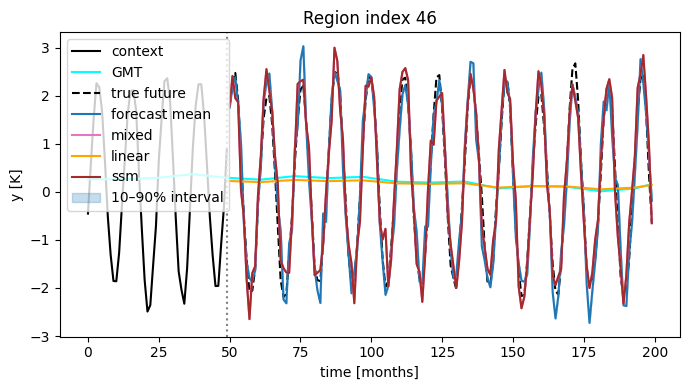

In [34]:
region = 46

extra_test_index =20
assert extra_test_index < offset
test_index = len(y)-offset+extra_test_index 


y_mix_trans = y_scaler.inverse_transform(y_mix.cpu().numpy())[:, :, region]
y_ssm_trans = y_scaler.inverse_transform(y_ssm.cpu().numpy())[:, :, region]
y_lin_trans = y_scaler.inverse_transform(y_lin.cpu().numpy())[:, :, region]


# Inverse transform predictions
mean = y_scaler.inverse_transform(mean_n.cpu().numpy())[:, :, region]
p10  = y_scaler.inverse_transform(p10_n.cpu().numpy())[:, :, region]
p90  = y_scaler.inverse_transform(p90_n.cpu().numpy())[:, :, region]
y_true = y[-offset:,-H:, region]   # unnormalized true future

#print(y_scaler.inverse_transform(mean_n.cpu().numpy())[:, :,0])

# Build time axis
t_ctx = np.arange(Tc)
t_fut = np.arange(Tc, Tc + H)

shift = len(y[0])-(Tc+H)
shifted_total=np.array(range(len(u[test_index,-(Tc+H):-1])))+shift


# for region in range(58):
#     # Plot
plt.figure(figsize=(7, 4))
#plt.plot(t_ctx, y[0, :Tc, 0], label="context", color="black")
plt.plot(t_ctx+shift, y[test_index,-(Tc+H):-H, region], label="context", color="black")
plt.plot(shifted_total,u[test_index,-(Tc+H):-1], label="GMT", color="cyan")
#plt.plot(t_ctx, y[1,-(Tc+H):-H, region], label="diff context", color="grey")
#plt.plot(t_ctx, y[2,-(Tc+H):-H, region], label="diff context", color="grey")
plt.plot(t_fut+shift, y_true[extra_test_index], label="true future", color="black", linestyle="--")
#plt.plot(t_fut, y_true[1], label="true future", color="grey", linestyle="--")
#plt.plot(t_fut, y_true[2], label="true future", color="grey", linestyle="--")
#plt.plot(prediction[:,region],label="pattern scaling",color="red")

plt.plot(t_fut+shift, mean[extra_test_index], label="forecast mean", color="tab:blue")
plt.plot(t_fut+shift, y_mix_trans[extra_test_index], label="mixed", color="tab:pink")
plt.plot(t_fut+shift, y_lin_trans[extra_test_index], label="linear", color="orange")
plt.plot(t_fut+shift, y_ssm_trans[extra_test_index], label="ssm", color="brown")
plt.fill_between(
    t_fut+shift,
    p10[extra_test_index],
    p90[extra_test_index],
    color="tab:blue",
    alpha=0.25,
    label="10–90% interval",
)
#plt.xlim([175,200])
plt.axvline(Tc - 1+shift, color="gray", linestyle=":")
#plt.ylim([-2,+2.5])
plt.legend()
plt.title(f"Region index {region}")
plt.xlabel("time [months]")
plt.ylabel("y [K]")
plt.tight_layout()
plt.show()

In [10]:
batch = 300
n_batches = int(len(y_n)/300)

region_names = ['ARO', 'ARP', 'ARS', 'BOB', 'CAF', 'CAR', 'CAU',
       'CNA', 'EAN', 'EAO', 'EAS', 'EAU', 'ECA', 'EEU', 'EIO', 'ENA', 'EPO',
       'ESAF', 'ESB', 'GIC', 'MDG', 'MED', 'NAO', 'NAU', 'NCA', 'NEAF', 'NEN',
       'NES', 'NEU', 'NPO', 'NSA', 'NWN', 'NWS', 'NZ', 'RAR', 'RFE', 'SAH',
       'SAM', 'SAO', 'SAS', 'SAU', 'SCA', 'SEA', 'SEAF', 'SES', 'SIO', 'SOO',
       'SPO', 'SSA', 'SWS', 'TIB', 'WAF', 'WAN', 'WCA', 'WCE', 'WNA', 'WSAF',
       'WSB','GLOBAL']

#n_batches = 3

region = region_names.index("RAR")

for i in range(n_batches):
    index1 = i*(batch) 
    index2 = (i+1)*batch
    y_ctx = torch.tensor(y_n[index1:index2,-(Tc+H):-H], dtype=torch.float32, device=device)
    u_ctx = torch.tensor(u_n[index1:index2,-(Tc+H):-H], dtype=torch.float32,device=device)
    u_fut = torch.tensor(u_n[index1:index2, -H:], dtype=torch.float32,device=device)
    
    # with torch.no_grad():
    #     mean_n, p10_n, p90_n = model.forecast(
    #         y_ctx, u_ctx, u_fut,
    #         steps=H,
    #         n_samples=200,
    #     )

    with torch.no_grad():
        y_mix, y_ssm, y_lin, score, w = forecast_with_u_fallback(
        model, y_ctx, u_ctx, u_fut, 
        mu_control, inv_cov_control, 
        tau_ood, 
        n_samples = 200,k=5.0
    )
    
    mean = y_scaler.inverse_transform(y_mix.cpu().numpy())[:, :, region]
    lin = y_scaler.inverse_transform(y_lin.cpu().numpy())[:, :, region]
    all_mean = [val[0] for val in mean]
    all_lin = [val[0] for val in lin]
    #all_mean = np.hstack([np.array(all_mean).squeeze(),mean[-1,1:]])
    if i==0:
        final_data = all_mean
        final_lin = all_lin
    else:
        final_data = np.hstack([final_data,all_mean])
        final_lin =  np.hstack([final_lin,all_lin])
    print(len(final_data))


300
600
900
1200
1500
1800
2100
2400
2700


In [60]:
region_names = ['ARO', 'ARP', 'ARS', 'BOB', 'CAF', 'CAR', 'CAU',
       'CNA', 'EAN', 'EAO', 'EAS', 'EAU', 'ECA', 'EEU', 'EIO', 'ENA', 'EPO',
       'ESAF', 'ESB', 'GIC', 'MDG', 'MED', 'NAO', 'NAU', 'NCA', 'NEAF', 'NEN',
       'NES', 'NEU', 'NPO', 'NSA', 'NWN', 'NWS', 'NZ', 'RAR', 'RFE', 'SAH',
       'SAM', 'SAO', 'SAS', 'SAU', 'SCA', 'SEA', 'SEAF', 'SES', 'SIO', 'SOO',
       'SPO', 'SSA', 'SWS', 'TIB', 'WAF', 'WAN', 'WCA', 'WCE', 'WNA', 'WSAF',
       'WSB','GLOBAL']
delta_index = 0

import regionmask
regions = regionmask.defined_regions.ar6.all
region_names = regions.abbrevs
print(region_names)
delta_index = 1
region = region_names.index("RAR")
region = region+delta_index

H= 150

y_true = [value for value in y[:,-H,region]][:len(final_data)]#y[-offset:,-H:, region]

gmt = [value for value in u[:,-H,0]][:len(final_data)]



#plt.figure(figsize = (10,7))
#plt.xlim([0,50])
#plt.plot(final_data)
#plt.plot(final_data)
plt.plot(final_data - y_true)
plt.figure(figsize = (15,5))
#plt.xlim([0,50])
plt.plot(final_data)
plt.plot(y_true)
plt.plot(final_lin)
plt.plot(gmt)
plt.figure(figsize = (15,5))
#plt.xlim([3500,4050])
plt.plot(final_data,label="ssm "+f"region {region_names[region]}")
plt.plot(y_true,label="truth")
plt.plot(final_lin,label="lin")
plt.plot(gmt,label="GMT")
plt.legend()


['GIC', 'NWN', 'NEN', 'WNA', 'CNA', 'ENA', 'NCA', 'SCA', 'CAR', 'NWS', 'NSA', 'NES', 'SAM', 'SWS', 'SES', 'SSA', 'NEU', 'WCE', 'EEU', 'MED', 'SAH', 'WAF', 'CAF', 'NEAF', 'SEAF', 'WSAF', 'ESAF', 'MDG', 'RAR', 'WSB', 'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS', 'SEA', 'NAU', 'CAU', 'EAU', 'SAU', 'NZ', 'EAN', 'WAN', 'ARO', 'NPO', 'EPO', 'SPO', 'NAO', 'EAO', 'SAO', 'ARS', 'BOB', 'EIO', 'SIO', 'SOO']


NameError: name 'final_data' is not defined

In [35]:
def center_histogram(histo: np.ndarray, bin_edges: np.ndarray):
    bins_centre = []
    for k in range(1, len(bin_edges)):
        bins_centre.append((bin_edges[k] + bin_edges[k - 1]) / 2.)
    return histo, bins_centre

def get_hist_vec(data, bins=10, rangeH=None, density=True):
    histo, bin_edge = np.histogram(data, bins=bins, range=rangeH, density=density)
    return center_histogram(histo, bin_edge)

def get_hist_vec_cum(data, bins=10, rangeH=None, density=True, cumulative=True):
    histo, bin_edge, _ = plt.hist(data, bins=bins, range=rangeH, density=density, cumulative=cumulative)
    plt.clf()
    return center_histogram(histo, bin_edge)

Text(0, 0.5, 'CDF for region RAR')

<Figure size 640x480 with 0 Axes>

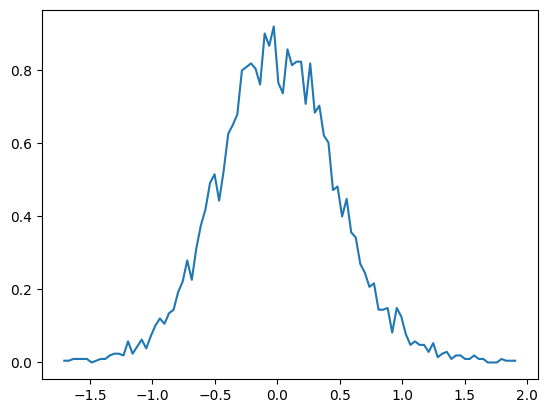

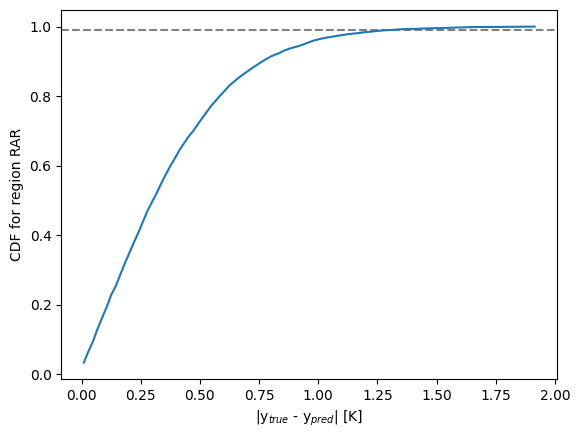

In [38]:
y_1, x_1 = get_hist_vec((final_data-y_true), bins=100)
y_cdf_1, x_cdf_1 = get_hist_vec_cum(np.abs(final_data-y_true), bins=100)
plt.figure()
plt.plot(x_1,y_1)
plt.figure()
plt.axhline(0.99,ls="--",color="grey")
plt.plot(x_cdf_1,y_cdf_1)
plt.xlabel("|y$_{true}$ - y$_{pred}$| [K]")

plt.ylabel("CDF for region "+f"{region_names[region]}")

In [36]:
h = 150
y_true = [value for value in y[:,-h]]

gmt = [value for value in u[:,-h,0]]

y_true = np.array(y_true)
gmt = np.array(gmt)

y_true = np.expand_dims(y_true,0)
gmt = np.expand_dims(gmt,0)
gmt = np.expand_dims(gmt,-1)
print(y_true.shape,gmt.shape)

y_t_n = y_scaler.transform(y_true)
u_t_n = u_scaler.transform(gmt)

y_tensor = torch.from_numpy(y_t_n).to(device).to(torch.float32)
u_tensor = torch.from_numpy(u_t_n).to(device).to(torch.float32)

Tc_test = 100
H = 150

y_past = y_tensor[:,-(Tc_test+H):-H,:]
u_past = u_tensor[:,-(Tc_test+H):-H,:]
u_future = u_tensor[:,-H:,:]

print(y_past.shape,u_past.shape,u_future.shape)




(1, 5810, 59) (1, 5810, 1)
torch.Size([1, 100, 59]) torch.Size([1, 100, 1]) torch.Size([1, 150, 1])


In [46]:
Tc_test = 100
H = 5000

y_past = y_tensor[:,-(Tc_test+H):-H,:]
u_past = u_tensor[:,-(Tc_test+H):-H,:]
u_future = u_tensor[:,-H:,:]

print(y_past.shape,u_past.shape,u_future.shape)

with torch.no_grad():
    y_mix, y_ssm, y_lin, score, w = forecast_with_u_fallback(
    model, y_past, u_past, u_future, 
    mu_control, inv_cov_control, 
    tau_ood, 
    n_samples = 1,k=5.0
)


torch.Size([1, 100, 59]) torch.Size([1, 100, 1]) torch.Size([1, 5000, 1])


In [38]:
#y_gt is ground truth
def get_variability_from_data(n_first_indices,y_gt):
    monthly_data=[]
    for i in range(12):
        monthly_data.append([])
        for j in np.arange(i,n_first_indices,12):
            monthly_data[i].append(y_gt[j])
        
    variability = np.zeros_like(y_gt)
    
    for i in range(12):
        for j in np.arange(i,len(variability),12):
            variability[j]=np.std(np.array(monthly_data[i]))
    return variability

-16.82333015171326 16.068048199988194


/scratch/slurm/2558558/ipykernel_1833652/3198616837.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_1, x_1 = get_hist_vec((y_pred-y_gt), bins=100)
/scratch/slurm/2558558/ipykernel_1833652/3198616837.py:30: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_cdf_1, x_cdf_1 = get_hist_vec_cum(np.abs(y_pred-y_gt), bins=100)
/scratch/slurm/2558558/ipykernel_1833652/3198616837.py:58: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(y_pred-y_gt, label = "y$_{pred}$ - y$_{gt}$")


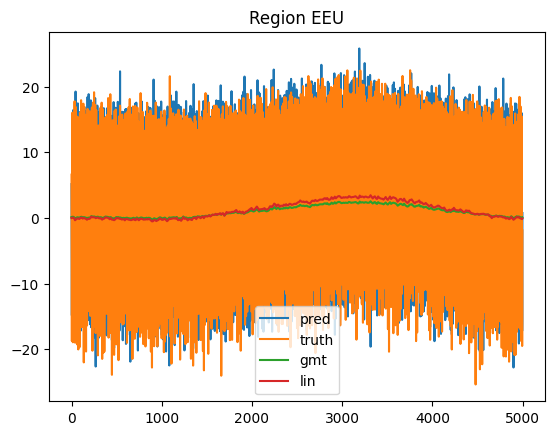

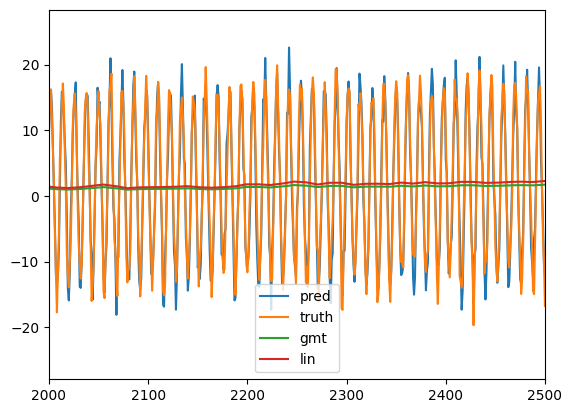

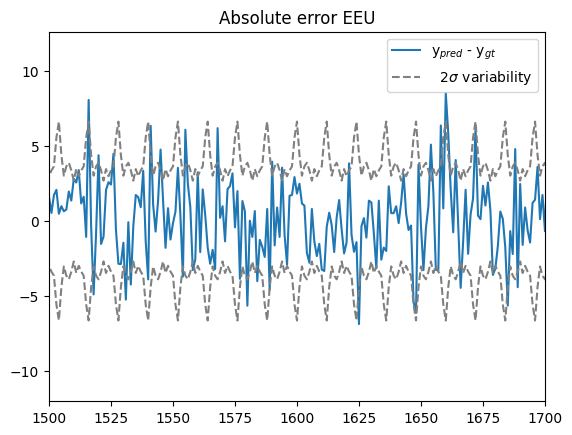

In [67]:
region_names = ['GLOBAL','ARO', 'ARP', 'ARS', 'BOB', 'CAF', 'CAR', 'CAU',
       'CNA', 'EAN', 'EAO', 'EAS', 'EAU', 'ECA', 'EEU', 'EIO', 'ENA', 'EPO',
       'ESAF', 'ESB', 'GIC', 'MDG', 'MED', 'NAO', 'NAU', 'NCA', 'NEAF', 'NEN',
       'NES', 'NEU', 'NPO', 'NSA', 'NWN', 'NWS', 'NZ', 'RAR', 'RFE', 'SAH',
       'SAM', 'SAO', 'SAS', 'SAU', 'SCA', 'SEA', 'SEAF', 'SES', 'SIO', 'SOO',
       'SPO', 'SSA', 'SWS', 'TIB', 'WAF', 'WAN', 'WCA', 'WCE', 'WNA', 'WSAF',
       'WSB'] # this is already corrected
delta_index = 0

# import regionmask
# regions = regionmask.defined_regions.ar6.all
# region_names = regions.abbrevs
# print(region_names)
# delta_index = 1
#print(abbrevs.index("GLOBAL"))

#n_batches = 3

region = region_names.index("EEU")
region = region+delta_index
y_pred = y_scaler.inverse_transform(y_ssm.cpu())[0,:,region]
y_pred_lin = y_scaler.inverse_transform(y_lin.cpu())[0,:,region]

y_gt = y_true[0,-H:,region]#y_t_n[0,-H:,region]


variability = get_variability_from_data(400,y_gt)

y_1, x_1 = get_hist_vec((y_pred-y_gt), bins=100)
y_cdf_1, x_cdf_1 = get_hist_vec_cum(np.abs(y_pred-y_gt), bins=100)

pi_period = 300
y_for_normalisation = y_gt[0:pi_period]-y_pred_lin[0:pi_period].cpu().numpy()
y_norm_max = np.percentile(y_for_normalisation,95)
y_norm_min = np.percentile(y_for_normalisation,5)
print(y_norm_min,y_norm_max)

plt.title(f"Region {region_names[region]}")
plt.plot(y_pred, label="pred")
plt.plot(y_gt,label="truth")
plt.plot(gmt[0,-H:,0],label="gmt")
plt.plot(y_pred_lin,label="lin")
plt.legend()
plt.figure()
plt.xlim([2000,2500])
plt.plot(y_pred,label="pred")
plt.plot(y_gt,label="truth")
plt.plot(gmt[0,-H:,0],label="gmt")
plt.plot(y_pred_lin,label="lin")
plt.legend()
# plt.figure()
# #plt.xlim([1500,2000])
# plt.title("Normalised error")
# plt.plot(((y_pred-y_gt)-y_norm_min)*2./(y_norm_max-y_norm_min)-1.)
plt.figure()
plt.title(f"Absolute error {region_names[region]}")
plt.xlim([1500,1700])
plt.plot(y_pred-y_gt, label = "y$_{pred}$ - y$_{gt}$")
plt.plot(variability*2,color="grey",ls="--",label = "  $2\sigma$ variability")
plt.plot(variability*(-2),color = "grey",ls="--")
plt.legend()
# plt.figure()
# plt.plot(x_cdf_1,y_cdf_1)
# plt.figure()
# plt.plot(x_1,y_1)


In [25]:
a = range(12)
print(a[-1])

11


/scratch/slurm/2558558/ipykernel_1833652/3786294358.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  error_along_time = ((y_pred-y_gt)-y_norm_min)*2./(y_norm_max-y_norm_min)-1.
/scratch/slurm/2558558/ipykernel_1833652/3786294358.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  error_along_time = y_pred-y_gt


10


/scratch/slurm/2558558/ipykernel_1833652/3786294358.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  error_along_time = ((y_pred-y_gt)-y_norm_min)*2./(y_norm_max-y_norm_min)-1.
/scratch/slurm/2558558/ipykernel_1833652/3786294358.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  error_along_time = y_pred-y_gt


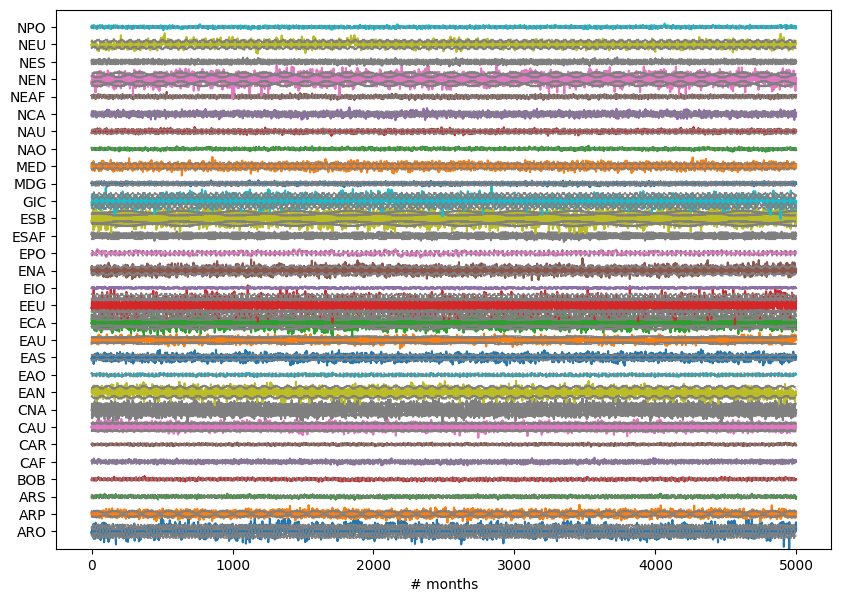

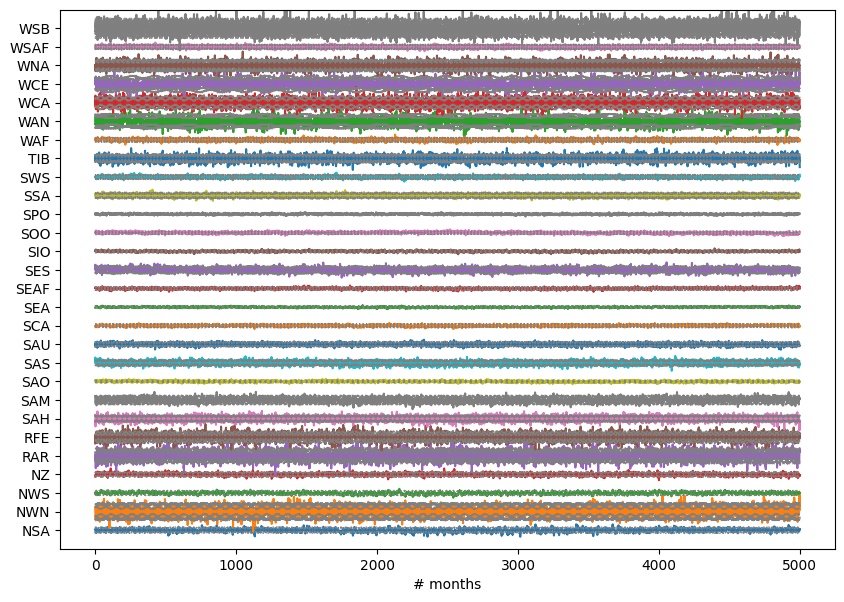

In [66]:
def prep_plot_all_region_errors(region):
    y_pred = y_scaler.inverse_transform(y_ssm.cpu())[0,:,region]
    y_pred_lin = y_scaler.inverse_transform(y_lin.cpu())[0,:,region]
    y_gt = y_true[0,-H:,region]
    variability = get_variability_from_data(400,y_gt)
    pi_period = 300
    y_for_normalisation = y_gt[0:pi_period]-y_pred_lin[0:pi_period].cpu().numpy()
    y_norm_max = np.percentile(y_for_normalisation,95)
    y_norm_min = np.percentile(y_for_normalisation,5)
    error_along_time = ((y_pred-y_gt)-y_norm_min)*2./(y_norm_max-y_norm_min)-1.
    error_along_time = y_pred-y_gt
    return error_along_time.cpu().numpy(),variability

region = region_names.index("EEU")
data = prep_plot_all_region_errors(region)
dy = 10#(data.min() - data.max()) * 0.7  # Crowd them a bit.
region_names_for_plot = region_names[1:]

print(dy)
n_rows = 30
fig,axd = plt.subplots(1,1,figsize = (10,7))
axd.set_xlabel('# months')
axd.set_ylim(-dy, n_rows * dy)
for i,region_name in enumerate(region_names_for_plot):
    if(i<n_rows):
        region = region_names.index(region_name)
        region = region +delta_index
        data,variab = prep_plot_all_region_errors(region)
        axd.plot(data+i*dy)
        axd.plot(variab*2+i*dy,color="grey",ls="dotted")
        axd.plot(variab*(-2)+i*dy,color="grey",ls="dotted")
    
axd.set_yticks([i*dy for i in range(n_rows)], labels=region_names_for_plot[0:n_rows])

fig,axd = plt.subplots(1,1,figsize = (10,7))
axd.set_xlabel('# months')
axd.set_ylim(-dy, (len(region_names_for_plot)-n_rows) * dy)
j = 0
for i,region_name in enumerate(region_names_for_plot):
    if(i>=n_rows):
        region = region_names.index(region_name)
        region= region+delta_index
        data,variab = prep_plot_all_region_errors(region)
        axd.plot(data+j*dy)
        axd.plot(variab*2+j*dy,color="grey",ls="dotted")
        axd.plot(variab*(-2)+j*dy,color="grey",ls="dotted")
        j+=1
    
axd.set_yticks([i*dy for i in range((len(region_names_for_plot)-n_rows))], labels=region_names_for_plot[n_rows:])
    
    # for i, data_col in enumerate(data.T):
    #     axd["EEG"].plot(t, data_col + i*dy, color="C0")


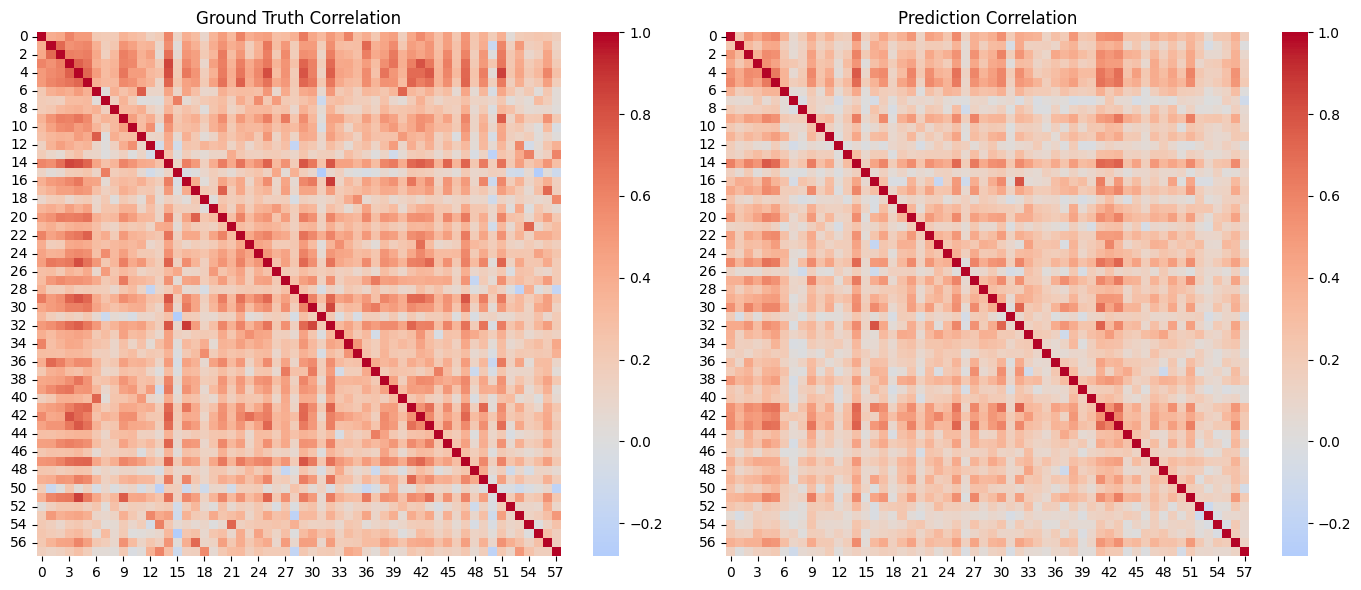

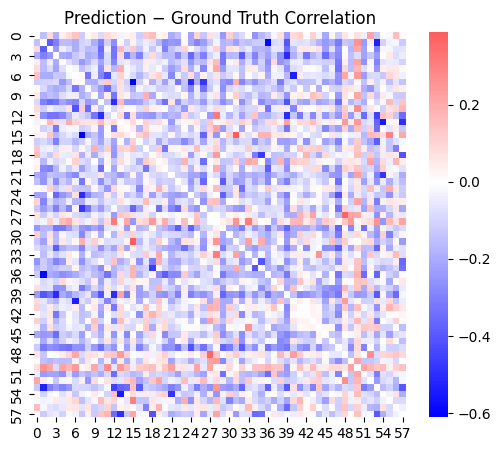

Correlation mismatch (Frobenius norm): 9.15778994301192
Mean absolute correlation error  0.12477847724214602
Std absolute correlation error  0.09674972339761391


In [65]:
import seaborn as sns

month = 1
end_phase = 2000

y_pred = y_scaler.inverse_transform(y_ssm.cpu().numpy())[0,:end_phase,1:]
y_gt = y_true[0,-H:]
y_gt = y_gt[:end_phase,1:]

y_pred_n = [y_pred[j] for j in np.arange(month,len(y_pred),12)]
y_pred=np.array(y_pred_n)
y_gt_n = [y_gt[j] for j in np.arange(month,len(y_gt),12)]
y_gt = np.array(y_gt_n)

# y_true, y_pred: shape (N, 59)

# Compute Pearson correlation matrices
corr_true = np.corrcoef(y_gt, rowvar=False)
corr_pred = np.corrcoef(y_pred, rowvar=False)

# Common color scale for fair comparison
vmin = min(corr_true.min(), corr_pred.min())
vmax = max(corr_true.max(), corr_pred.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(corr_true, ax=axes[0], vmin=vmin, vmax=vmax, cmap="coolwarm", center=0)
axes[0].set_title("Ground Truth Correlation")

sns.heatmap(corr_pred, ax=axes[1], vmin=vmin, vmax=vmax, cmap="coolwarm", center=0)
axes[1].set_title("Prediction Correlation")

plt.tight_layout()

corr_diff = corr_pred - corr_true

plt.figure(figsize=(6, 5))
sns.heatmap(corr_diff, cmap="bwr", center=0)
plt.title("Prediction − Ground Truth Correlation")
plt.show()

fro_norm = np.linalg.norm(corr_pred - corr_true, ord="fro")
print("Correlation mismatch (Frobenius norm):", fro_norm)
mean_abs_diff = np.mean(np.abs(corr_pred - corr_true))
std_abs_diff = np.std(np.abs(corr_pred - corr_true))
print("Mean absolute correlation error ", mean_abs_diff)
print("Std absolute correlation error ",std_abs_diff)

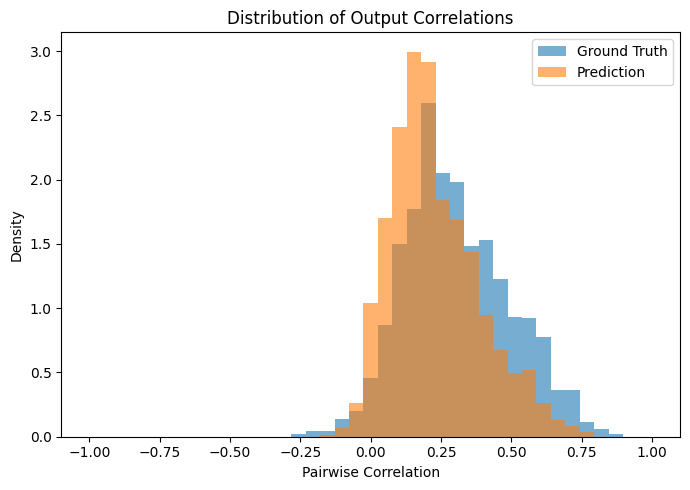

In [59]:
def upper_triangle_values(M):
    """Extract upper-triangle (excluding diagonal) values."""
    iu = np.triu_indices_from(M, k=1)
    return M[iu]

# Correlation matrices
corr_true = np.corrcoef(y_gt, rowvar=False)
corr_pred = np.corrcoef(y_pred, rowvar=False)

# Extract unique correlations (59*58/2 = 1711 values)
vals_true = upper_triangle_values(corr_true)
vals_pred = upper_triangle_values(corr_pred)

# Shared bins for fair comparison
bins = np.linspace(-1, 1, 40)

plt.figure(figsize=(7,5))

plt.hist(vals_true, bins=bins, alpha=0.6, density=True, label="Ground Truth")
plt.hist(vals_pred, bins=bins, alpha=0.6, density=True, label="Prediction")

plt.xlabel("Pairwise Correlation")
plt.ylabel("Density")
plt.title("Distribution of Output Correlations")
plt.legend()
plt.tight_layout()
plt.show()


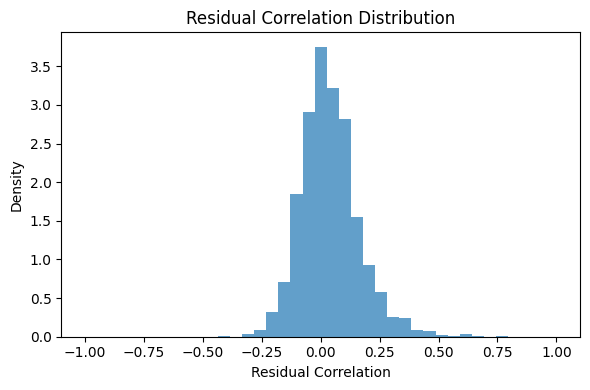

In [60]:
residuals = y_pred - y_gt
corr_res = np.corrcoef(residuals, rowvar=False)
vals_res = upper_triangle_values(corr_res)

plt.figure(figsize=(6,4))
plt.hist(vals_res, bins=bins, alpha=0.7, density=True)
plt.xlabel("Residual Correlation")
plt.ylabel("Density")
plt.title("Residual Correlation Distribution")
plt.tight_layout()
plt.show()


In [62]:
import numpy as np
#not sure whether that test is so interesting...


def upper_triangle(M):
    return M[np.triu_indices_from(M, k=1)]

# Residuals
R = y_pred - y_gt
N, D = R.shape

# Observed residual correlations
corr_obs = np.corrcoef(R, rowvar=False)
obs_vals = np.abs(upper_triangle(corr_obs))
obs_max = obs_vals.max()
obs_mean = obs_vals.mean()

# Null distribution via permutation
n_perm = 1000
max_null = []
mean_null = []

for _ in range(n_perm):
    R_perm = R.copy()

    # independently permute samples per dimension
    for d in range(D):
        np.random.shuffle(R_perm[:, d])

    C = np.corrcoef(R_perm, rowvar=False)
    vals = np.abs(upper_triangle(C))

    max_null.append(vals.max())
    mean_null.append(vals.mean())

max_null = np.array(max_null)
mean_null = np.array(mean_null)

p_max = np.mean(max_null >= obs_max)
p_mean = np.mean(mean_null >= obs_mean)

print("Observed max |corr|:", obs_max)
print("Permutation p (max):", p_max)

print("Observed mean |corr|:", obs_mean)
print("Permutation p (mean):", p_mean)


Observed max |corr|: 0.7782292014543093
Permutation p (max): 0.0
Observed mean |corr|: 0.09667934788682843
Permutation p (mean): 0.0


In [36]:

def correlation_matrix(X):
    return np.corrcoef(X, rowvar=False)

def frobenius_distance(A, B):
    return np.linalg.norm(A - B, ord="fro")

# Observed statistic
R_true = correlation_matrix(y_gt)
R_pred = correlation_matrix(y_pred)
T_obs = frobenius_distance(R_pred, R_true)

# Bootstrap
n_boot = 1000
N = y_gt.shape[0]
boot_stats = []

for _ in range(n_boot):
    idx = np.random.choice(N, N, replace=True)
    R_t = correlation_matrix(y_gt[idx])
    R_p = correlation_matrix(y_pred[idx])
    boot_stats.append(frobenius_distance(R_p, R_t))

boot_stats = np.array(boot_stats)

# p-value (two-sided style logic)
p_value = np.mean(boot_stats >= T_obs)

print("Observed statistic:", T_obs)
print("Bootstrap p-value:", p_value)


Observed statistic: 5.691175077804806
Bootstrap p-value: 0.965


In [23]:
import regionmask
regions = regionmask.defined_regions.ar6.all
abbrevs = regions.abbrevs
print(abbrevs)
print(abbrevs.index("GLOBAL"))

['GIC', 'NWN', 'NEN', 'WNA', 'CNA', 'ENA', 'NCA', 'SCA', 'CAR', 'NWS', 'NSA', 'NES', 'SAM', 'SWS', 'SES', 'SSA', 'NEU', 'WCE', 'EEU', 'MED', 'SAH', 'WAF', 'CAF', 'NEAF', 'SEAF', 'WSAF', 'ESAF', 'MDG', 'RAR', 'WSB', 'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS', 'SEA', 'NAU', 'CAU', 'EAU', 'SAU', 'NZ', 'EAN', 'WAN', 'ARO', 'NPO', 'EPO', 'SPO', 'NAO', 'EAO', 'SAO', 'ARS', 'BOB', 'EIO', 'SIO', 'SOO']


ValueError: 'GLOBAL' is not in list

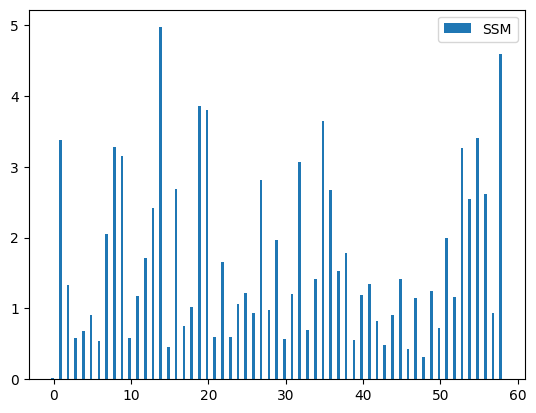

In [95]:
y_true = y[test_index,-H:].T

ssm_inference= y_scaler.inverse_transform(mean_n.cpu().numpy())[extra_test_index].T
#pattern_scaling = prediction[-H:].T

error = []

# for (x,m) in zip(ssm_inference,y_true):
#     z = np.max(np.abs(x-m))
#     print(z)

ssm_prediction_error = [np.sum(np.abs(x-y))/59 for x,y in zip(ssm_inference,y_true)]
#ps_prediction_error =  [np.sum(np.abs(x-y))/59 for x,y in zip(pattern_scaling,y_true)]

#ssm_prediction_error = [np.sqrt(np.sum((x-y)*(x-y))/59) for x,y in zip(ssm_inference,y_true)]
#ps_prediction_error =  [np.sqrt(np.sum((x-y)*(x-y))/59) for x,y in zip(pattern_scaling,y_true)]
#print(np.array(ssm_prediction_error).shape,np.array(ps_prediction_error).shape)

width = 0.35
#plt.ylim([0,1])
plt.bar(np.arange(len(ssm_prediction_error))-width/2,ssm_prediction_error,width,label="SSM")
#plt.bar(np.arange(len(ssm_prediction_error))+width/2,ps_prediction_error,width,label = "pattern scaling")
plt.legend()

In [36]:
def iterative_forecast(matrix, gmt_array, model, quantiles = None):
    """
    Iteratively forecasts regional temperatures using a RandomForestRegressor.
    
    Parameters:
    ----------
    matrix : np.ndarray
        Shape (1 + number_regions, n), 
        First row: GMT values from t-n to t
        Other rows: regional temps from t-n-1 to t-1
        
    gmt_array : np.ndarray
        1D array of GMT values, indexed from t+1 onward
        
    model : trained RandomForestRegressor
        Takes matrix as input and predicts regional temp at time t
        
    Returns:
    -------
    np.ndarray
        Full time series of predicted regional temperatures
        Shape: (number_regions, total_timesteps_predicted)
    """
    
    num_regions = matrix.shape[0] - 1
    n = matrix.shape[1]
    
    # Store predictions over time
    predictions_over_time = []

    # Index to iterate through GMT array
    gmt_index = n  # since matrix already holds GMT up to t
    
    while gmt_index < len(gmt_array):

        # Step 1: Prepare input (flatten matrix or reshape as needed by model)
        model_input = matrix.flatten().reshape(1, -1)
        
        # Step 2: Predict regional temperature at time t
        pred = model.predict(model_input).flatten()  # shape (num_regions,)
        if quantiles is not None: 
            all_preds = np.array([tree.predict(x.reshape(1, -1))[0]
                          for tree in model.estimators_])
            q_values = {dim: {q: np.quantile(all_preds[:, dim], q) for q in quantiles}
                for dim in range(all_preds.shape[1])}

        predictions_over_time.append(pred)
        
        # Step 3: Update matrix
        
        # Shift all columns left (remove first column)
        matrix = np.roll(matrix, shift=-1, axis=1)
        
        # Insert new GMT value in first row, last col
        matrix[0, -1] = gmt_array[gmt_index]
        
        # Insert predicted regional temps in remaining rows
        matrix[1:, -1] = pred
        
        # Move to next GMT value
        gmt_index += 1
    
    return np.array(predictions_over_time).T

output_autoregression = iterative_forecast(test_data_for_autoregression_input[:,:,0], gmt_autoregressive_test, model)

AttributeError: 'DeepSSMConditioned' object has no attribute 'predict'

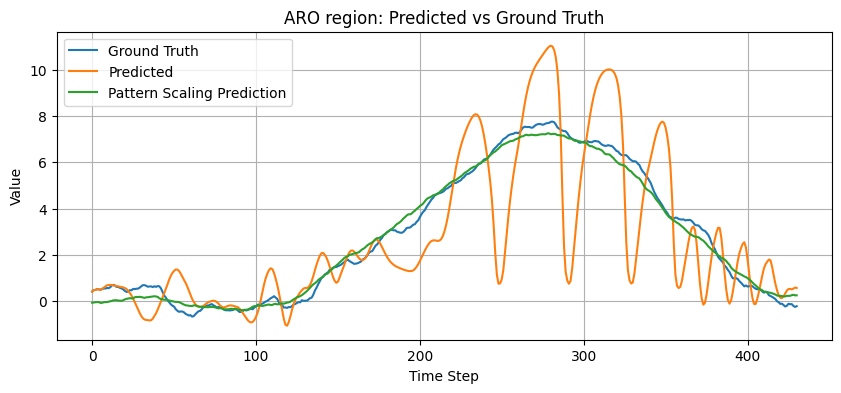

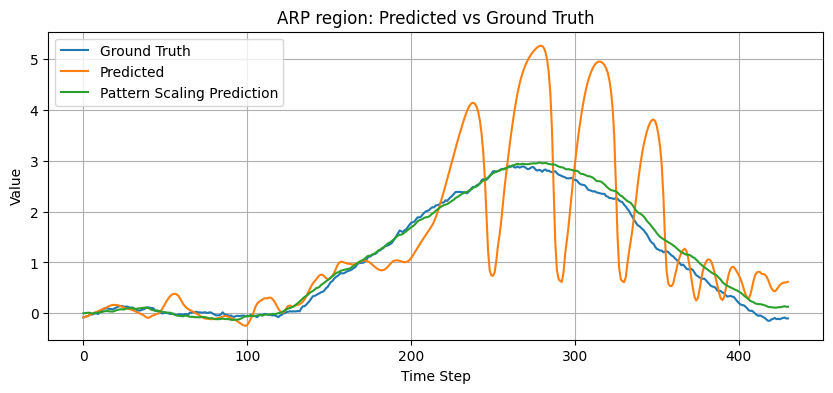

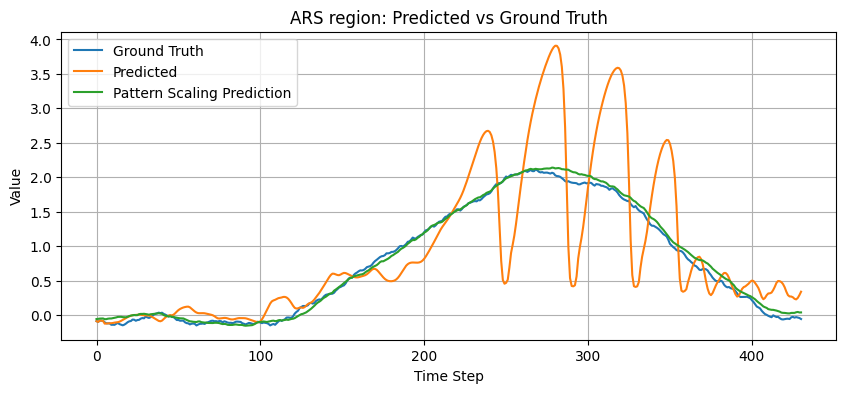

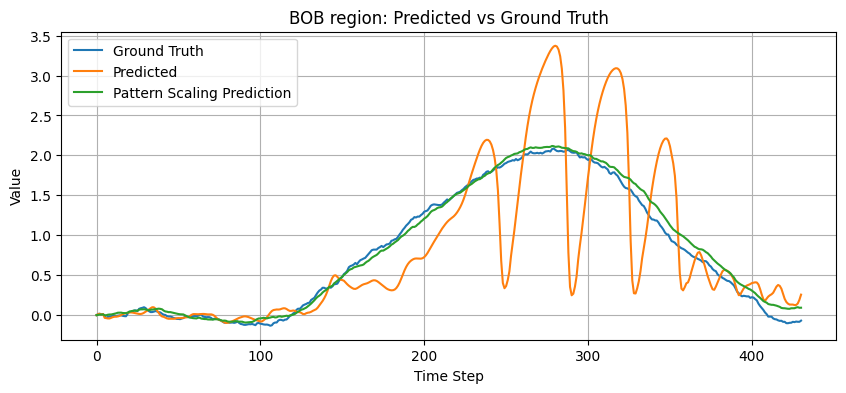

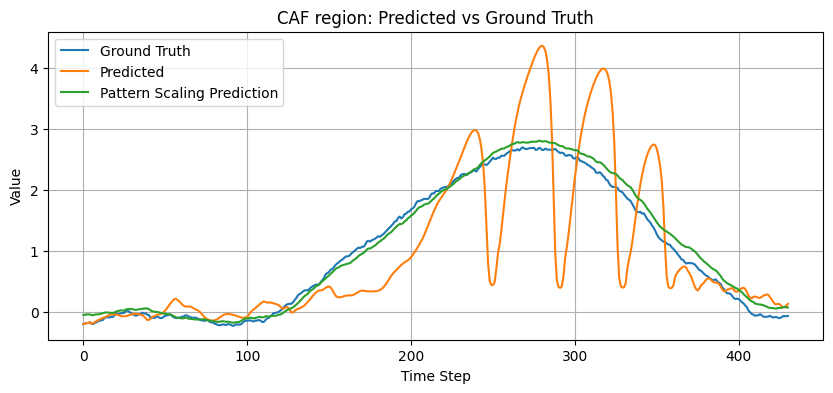

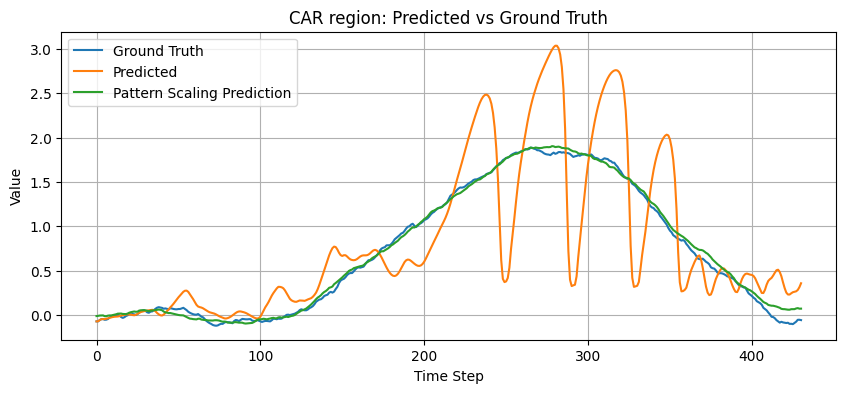

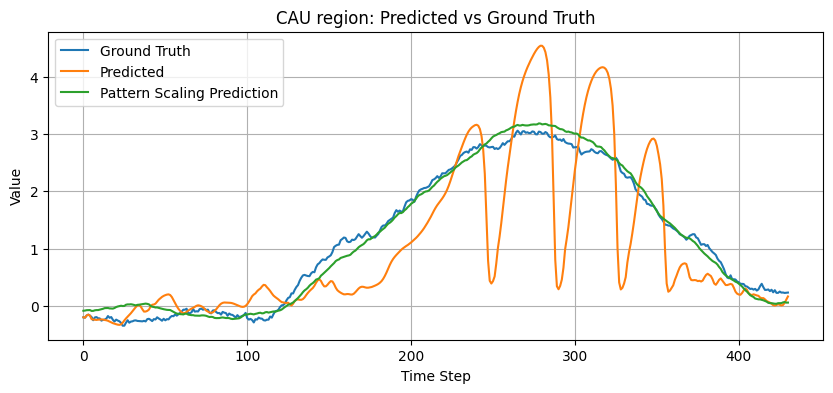

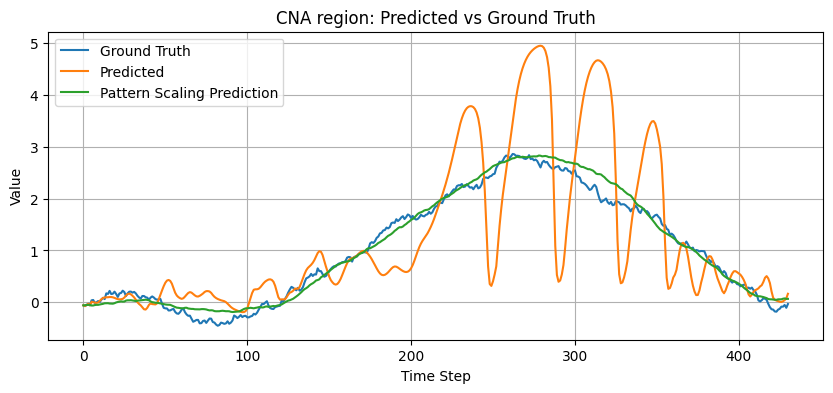

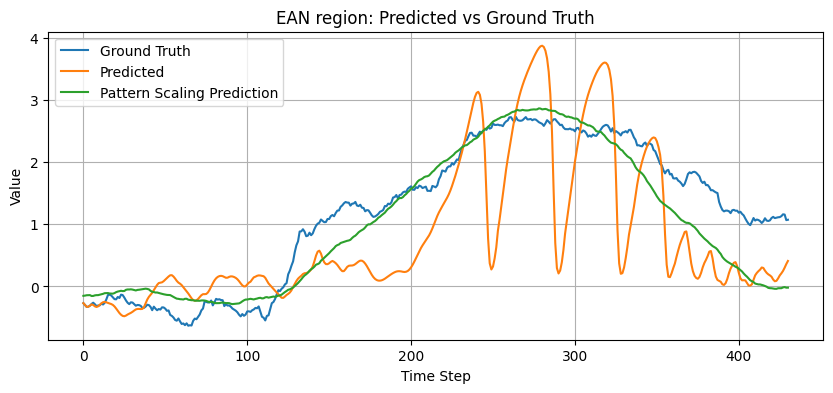

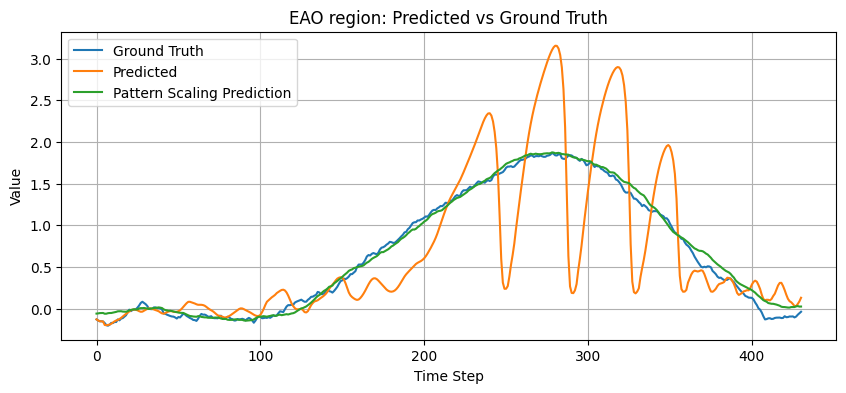

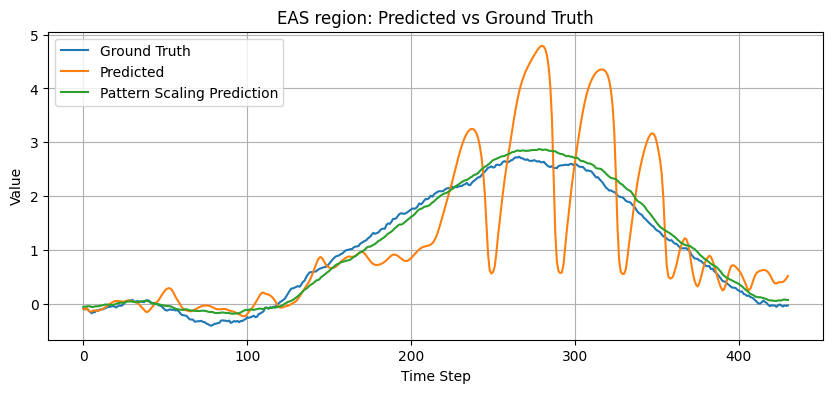

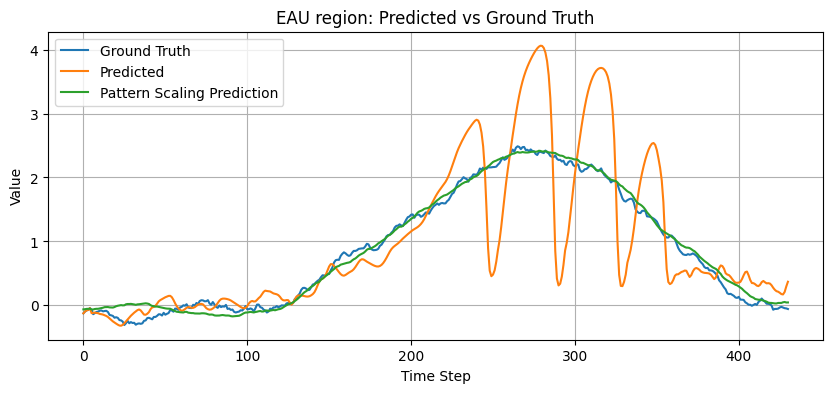

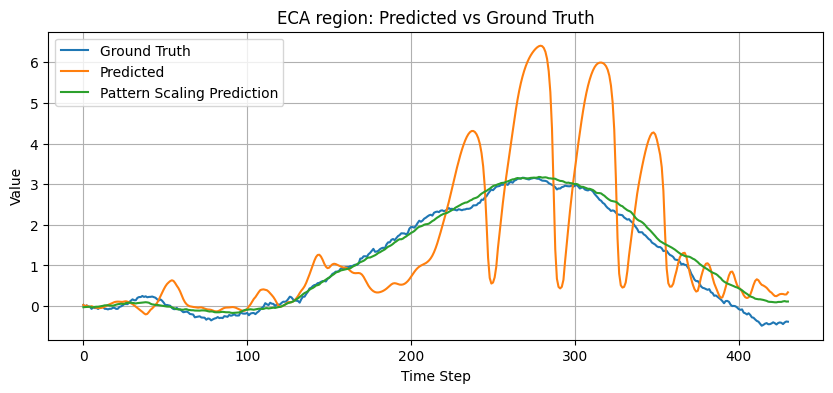

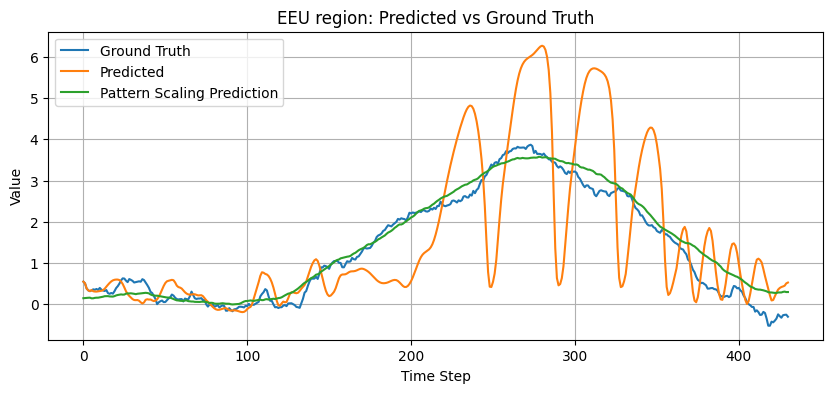

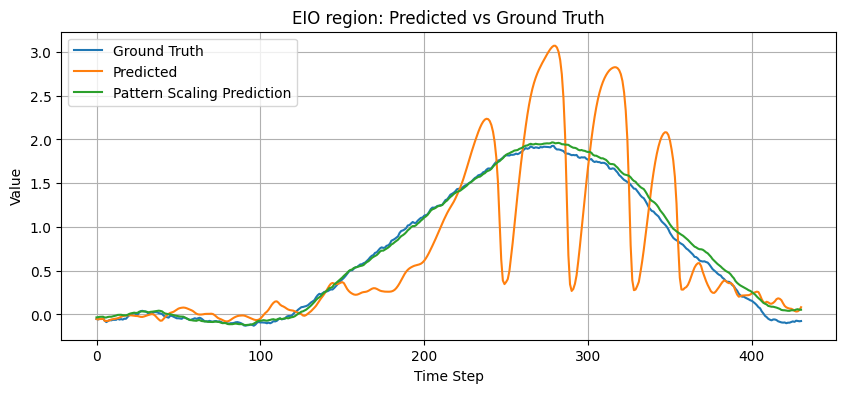

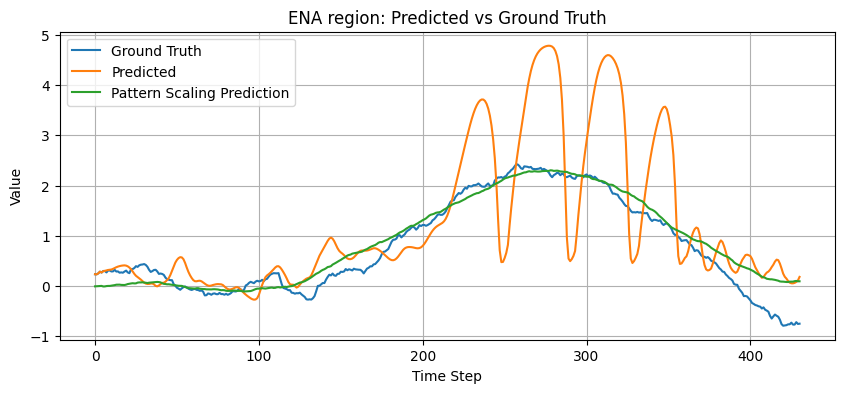

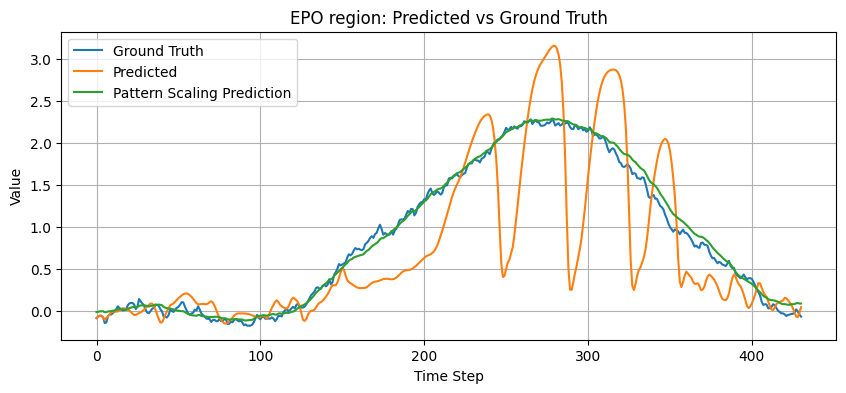

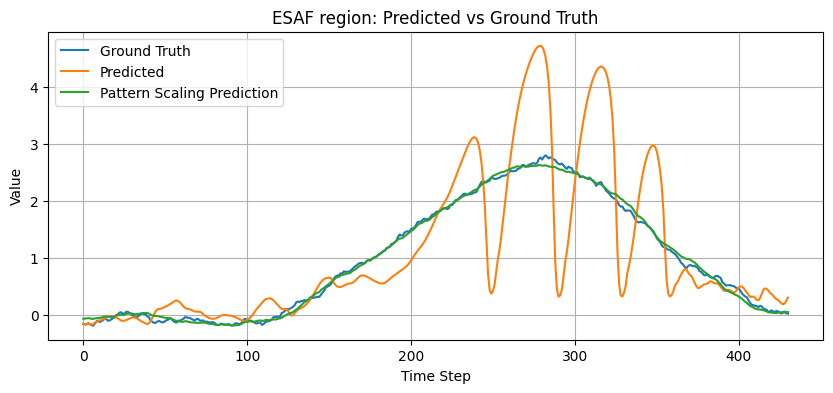

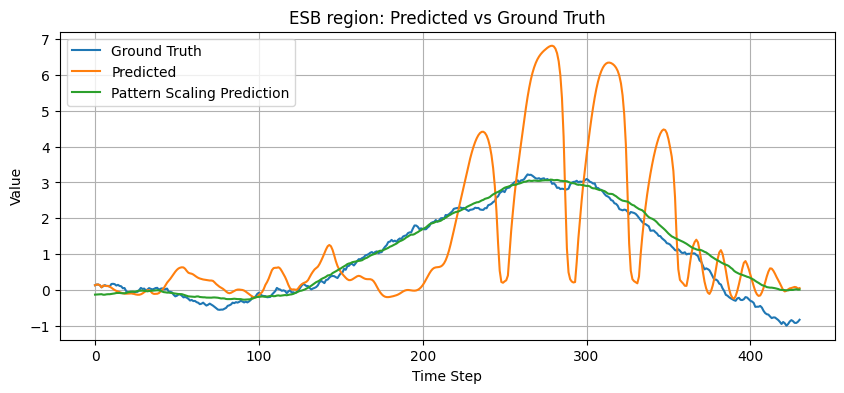

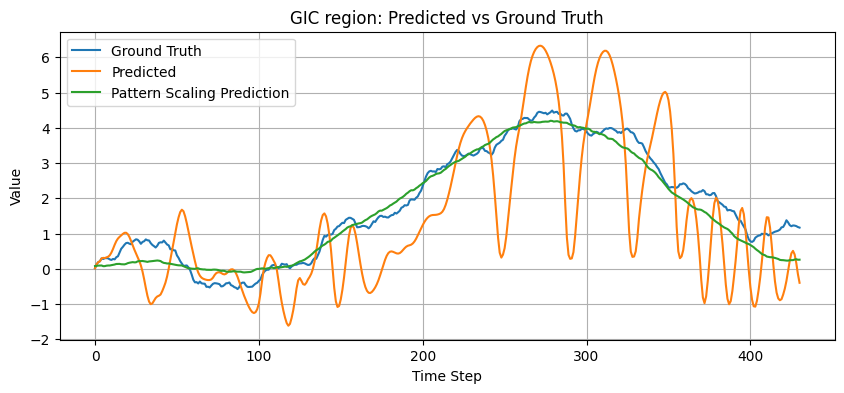

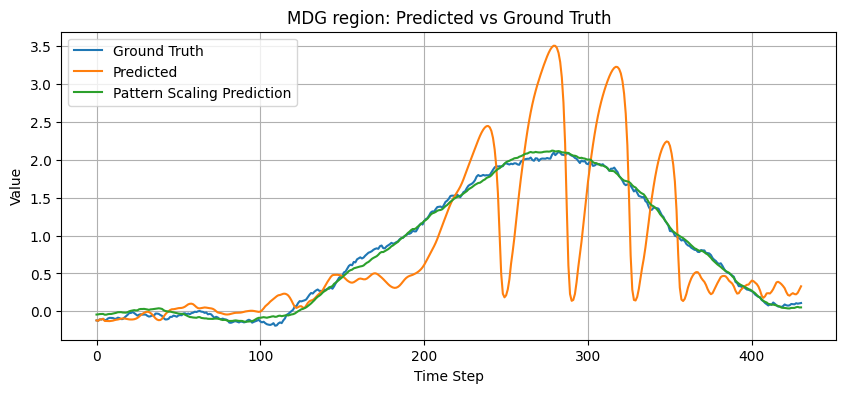

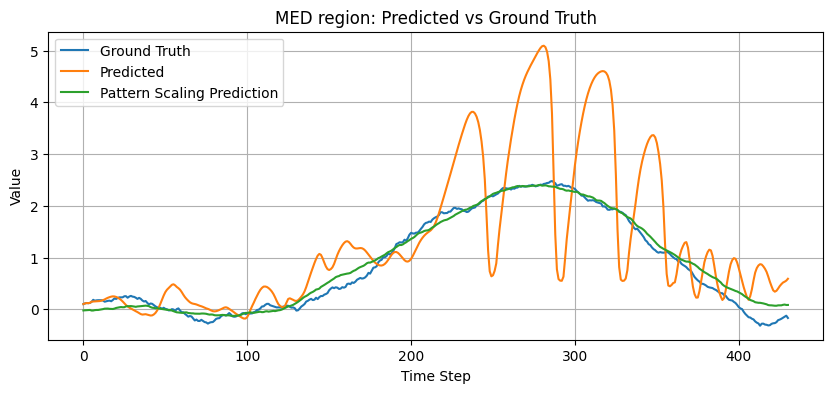

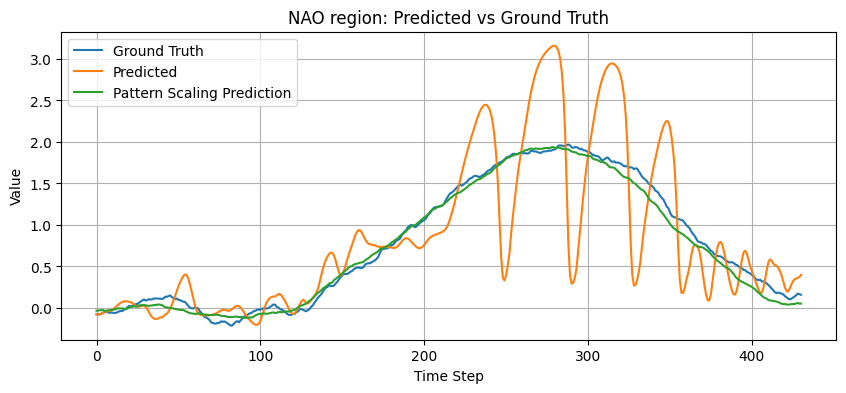

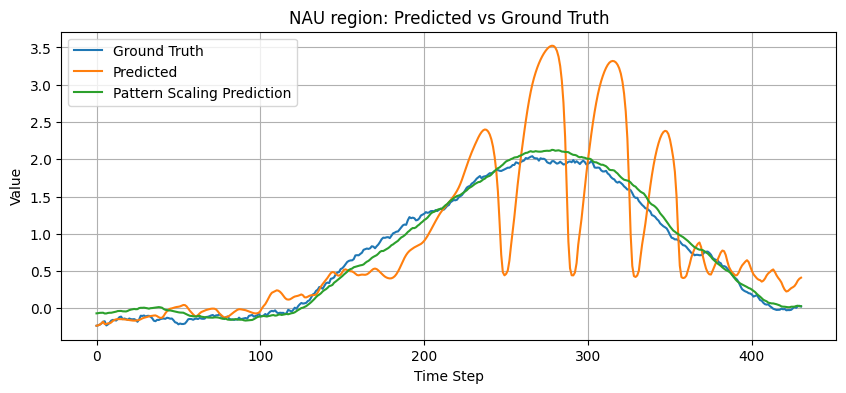

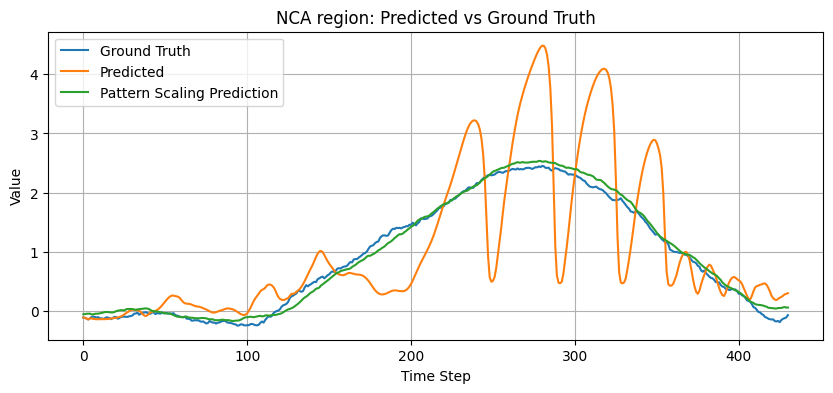

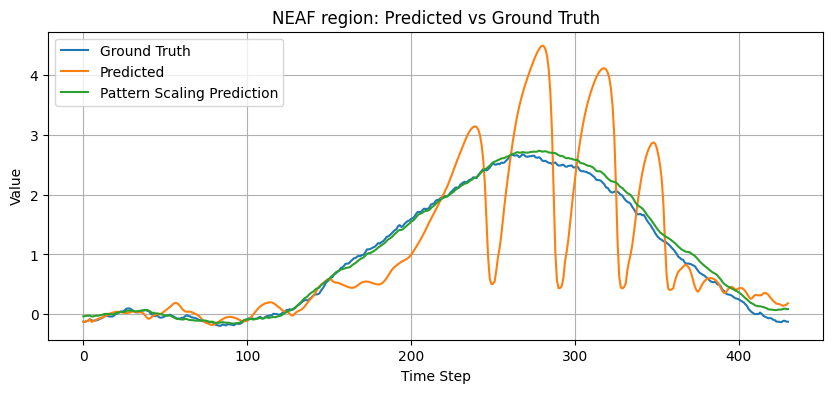

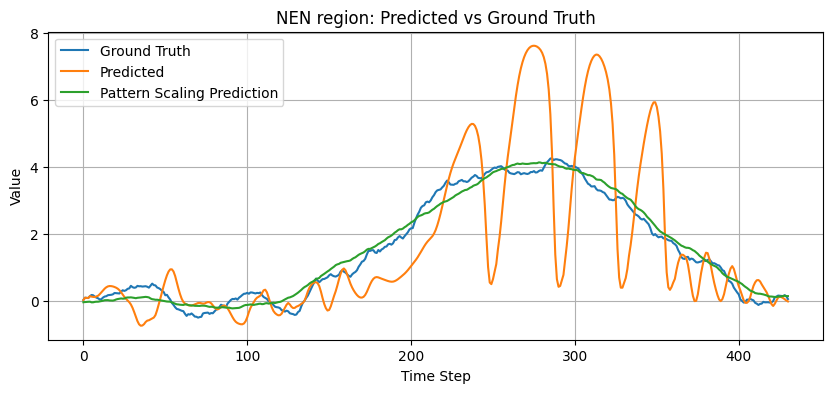

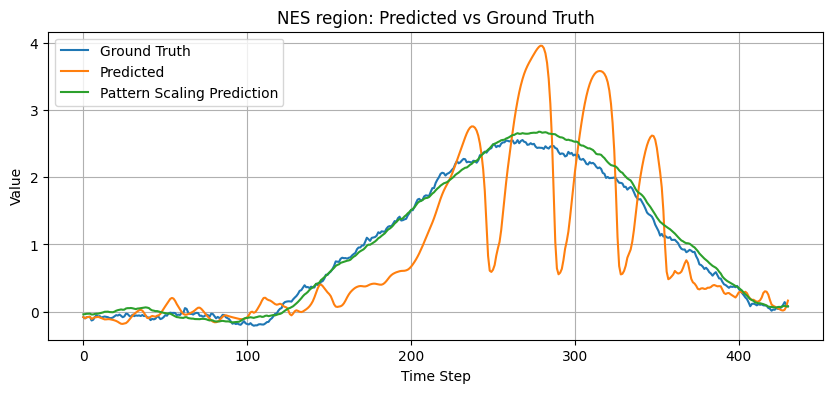

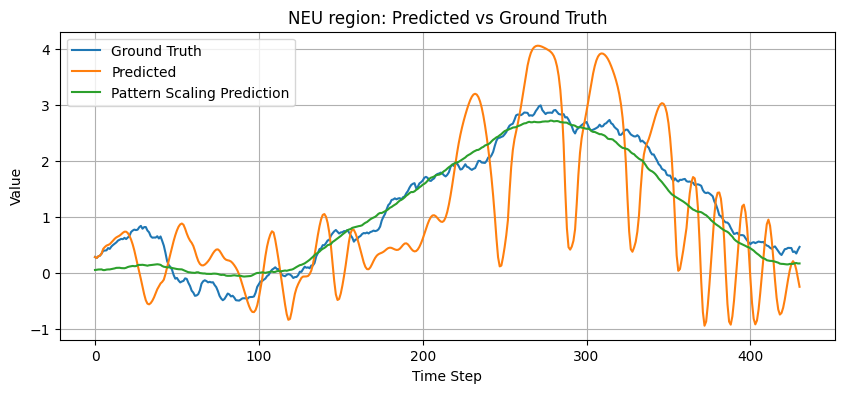

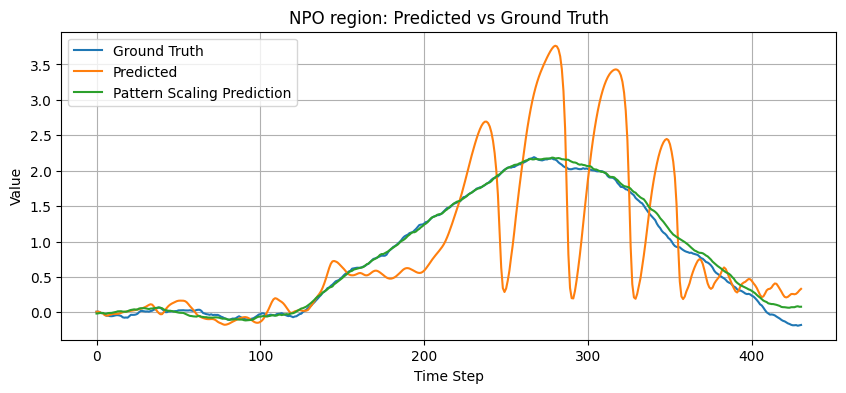

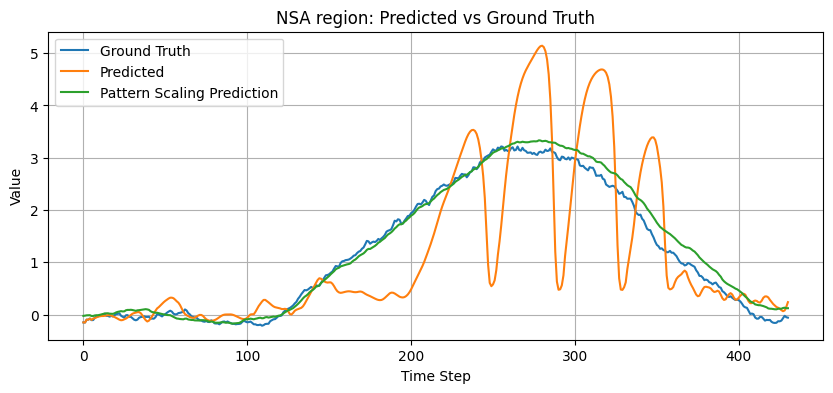

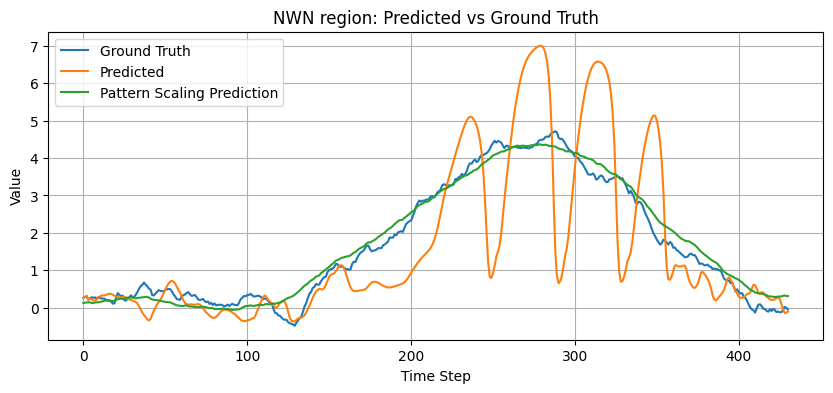

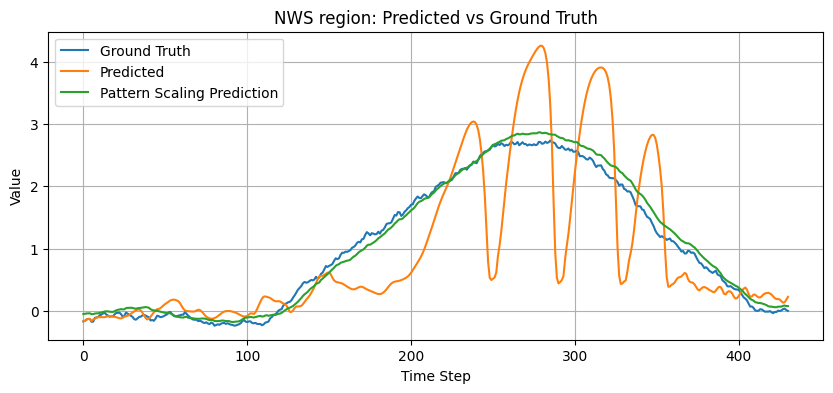

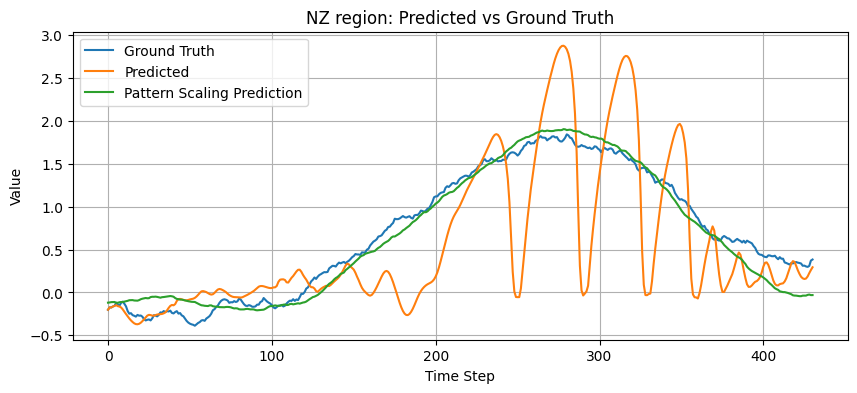

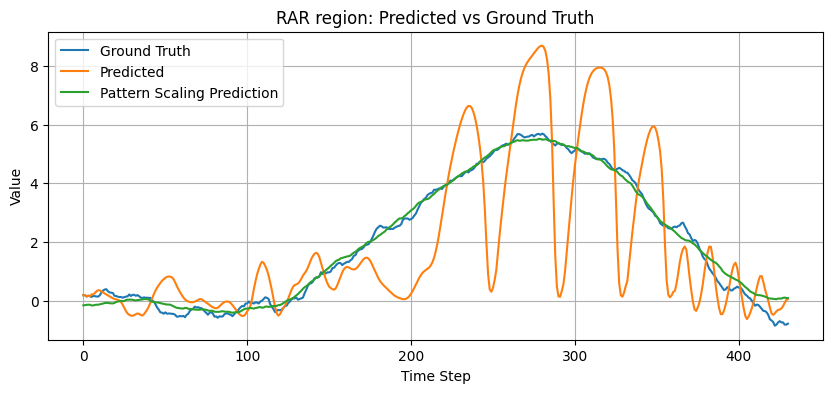

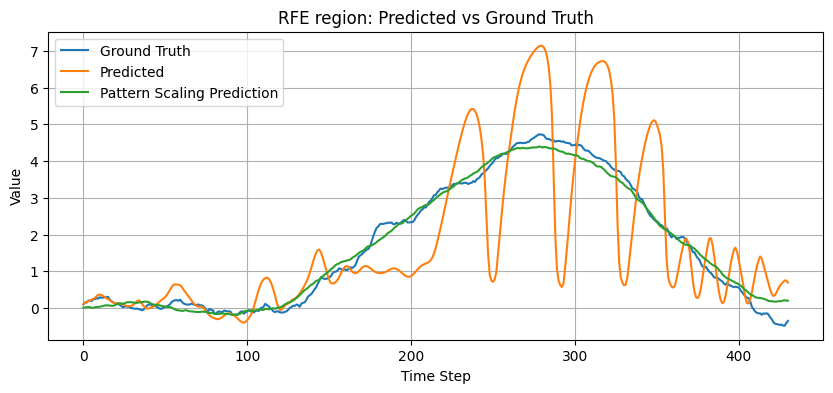

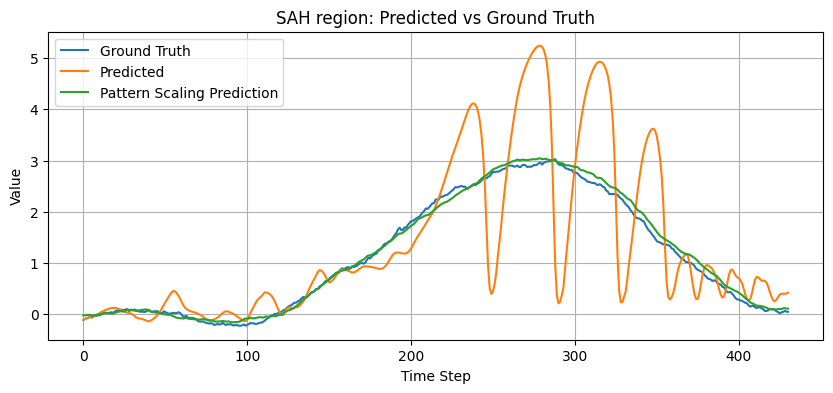

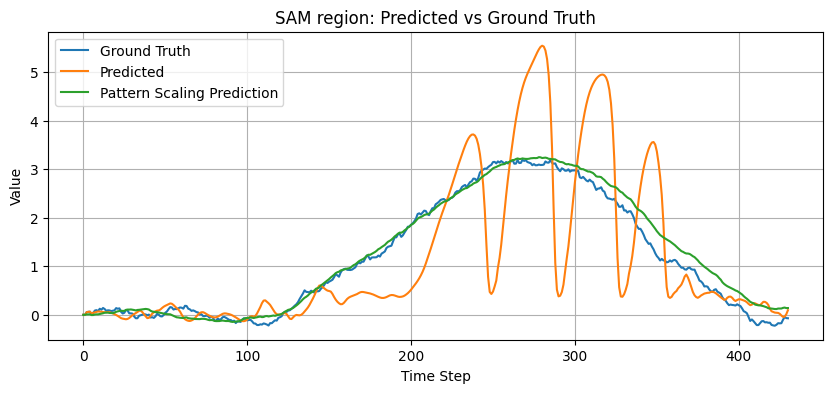

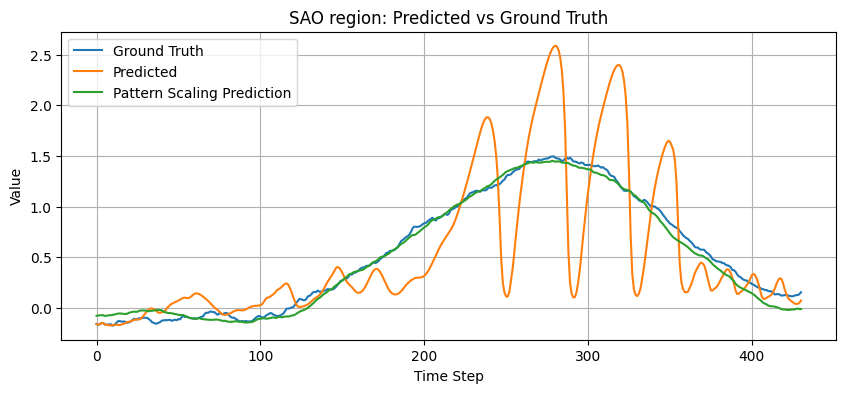

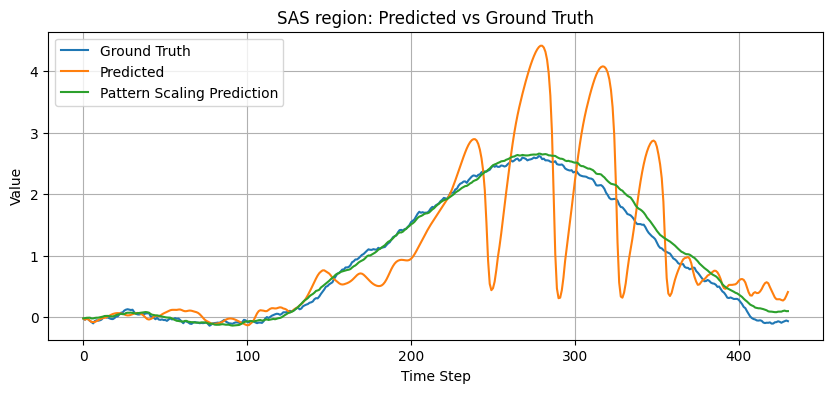

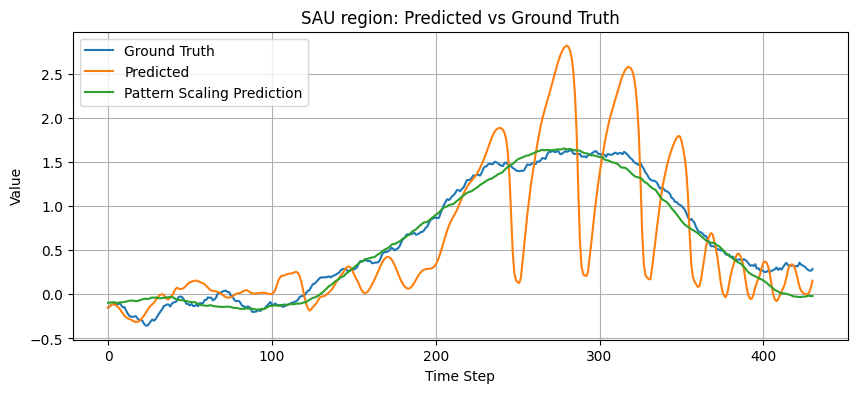

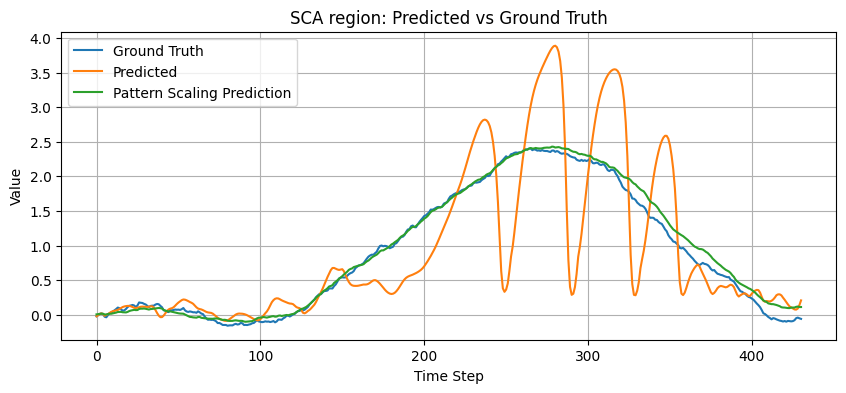

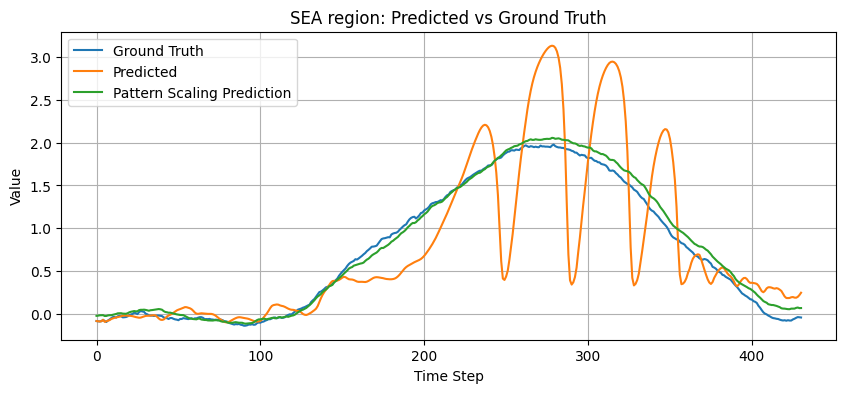

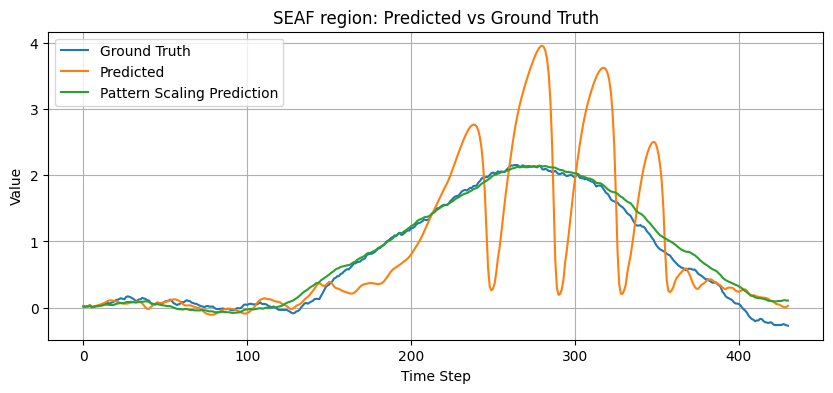

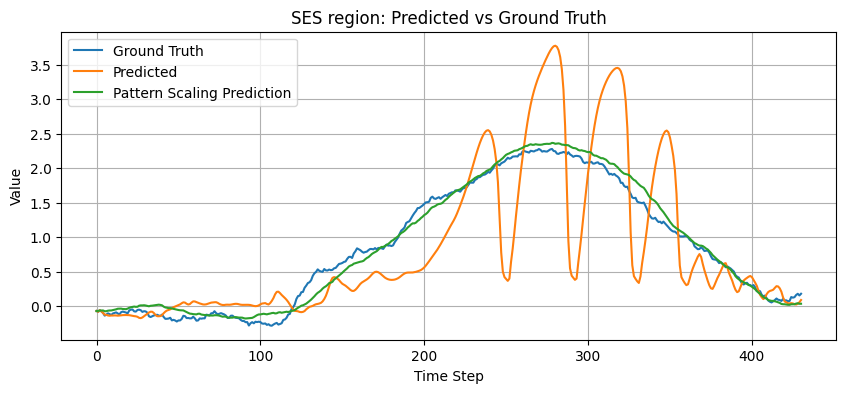

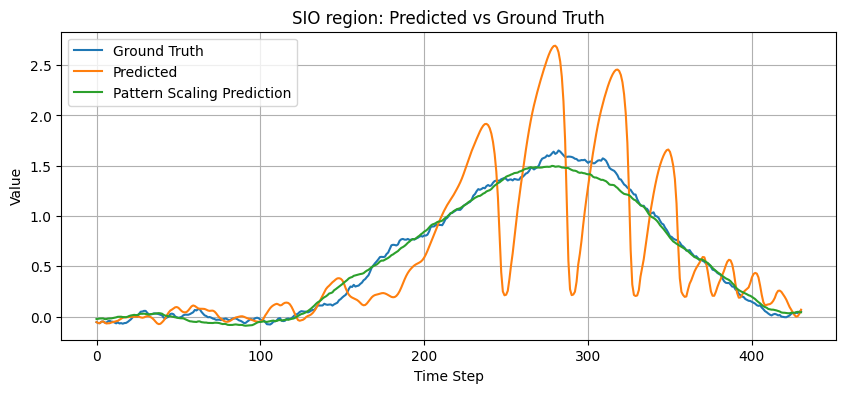

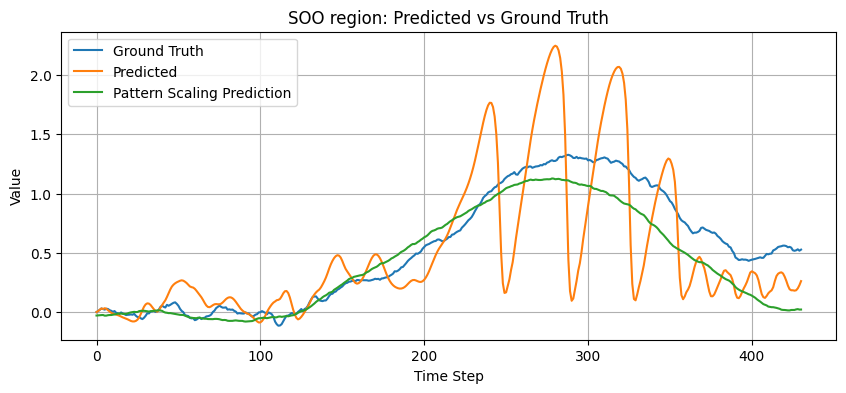

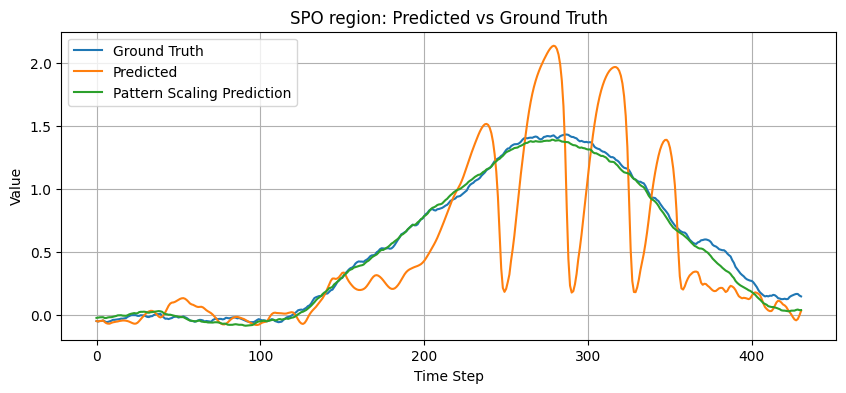

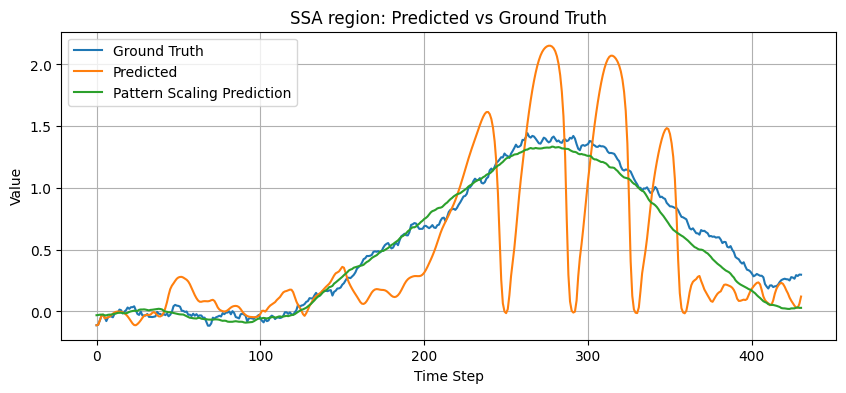

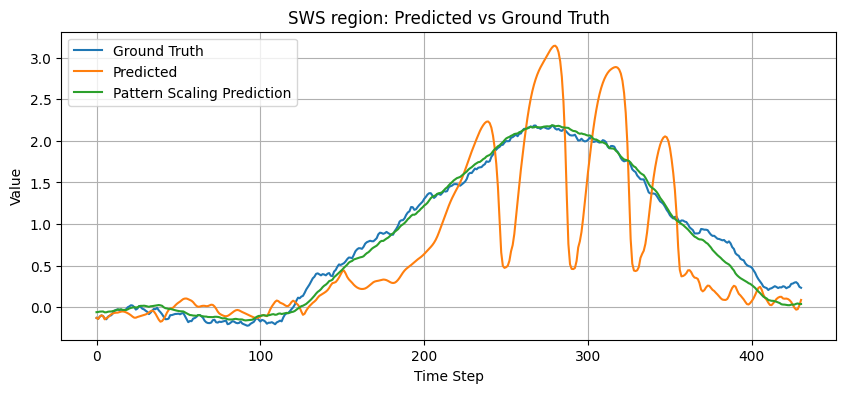

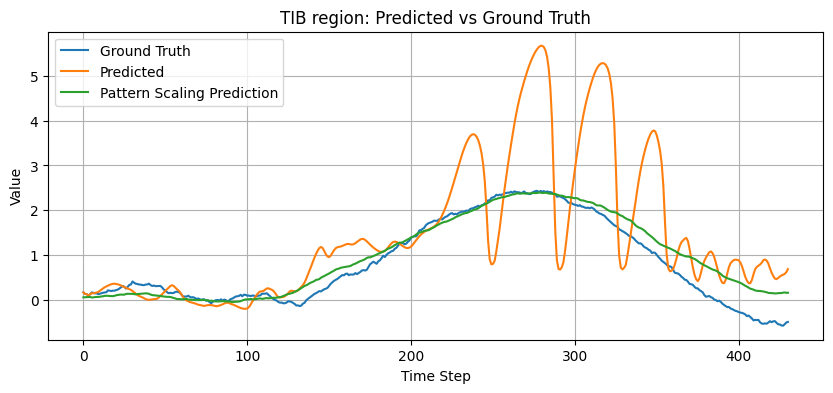

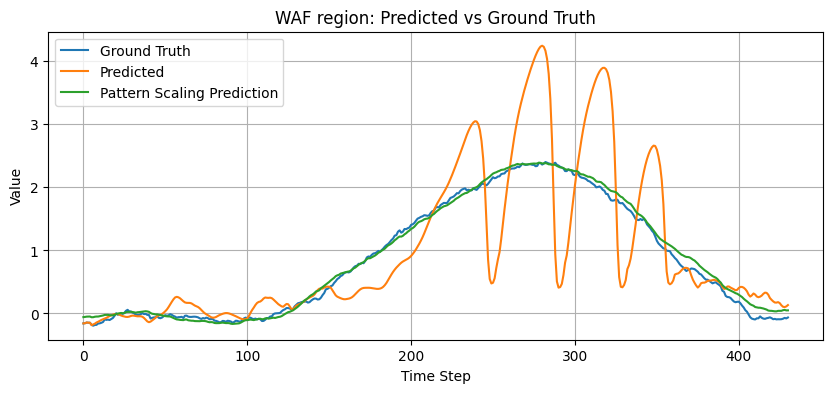

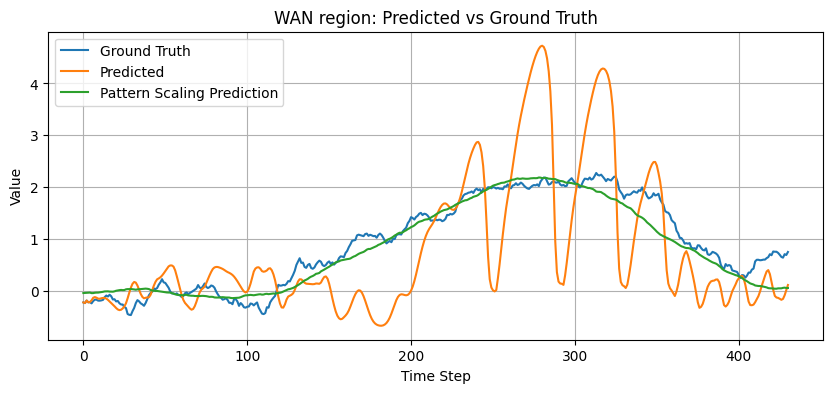

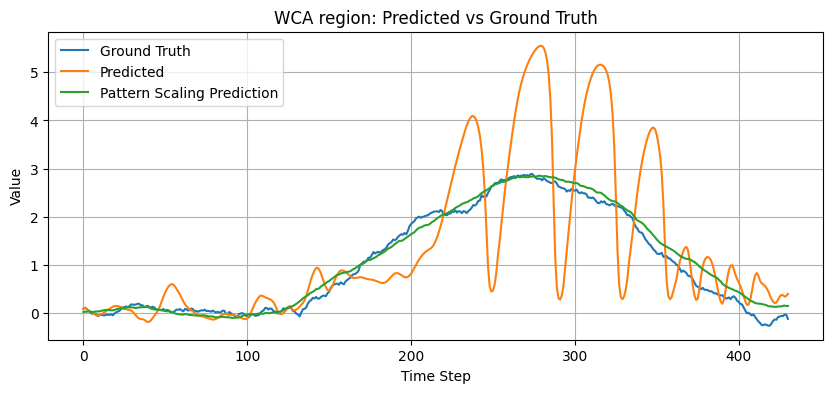

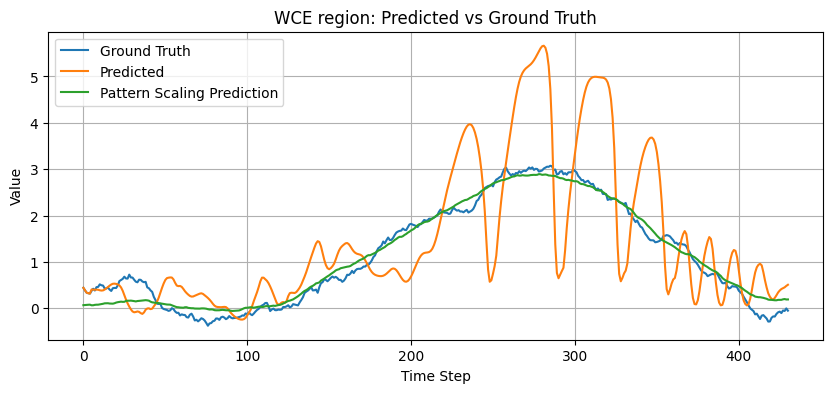

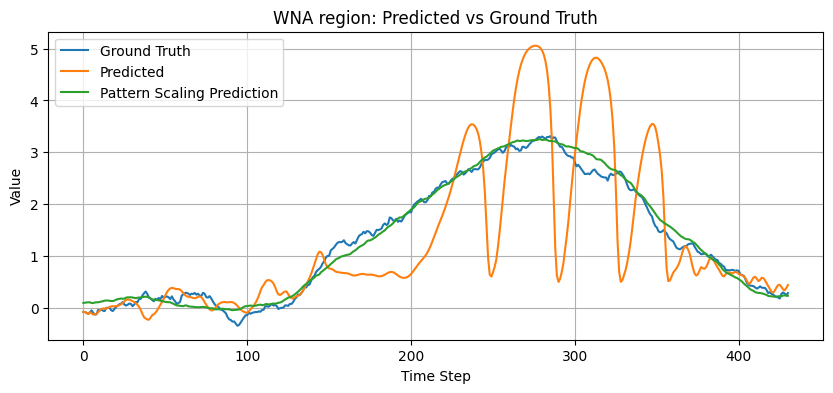

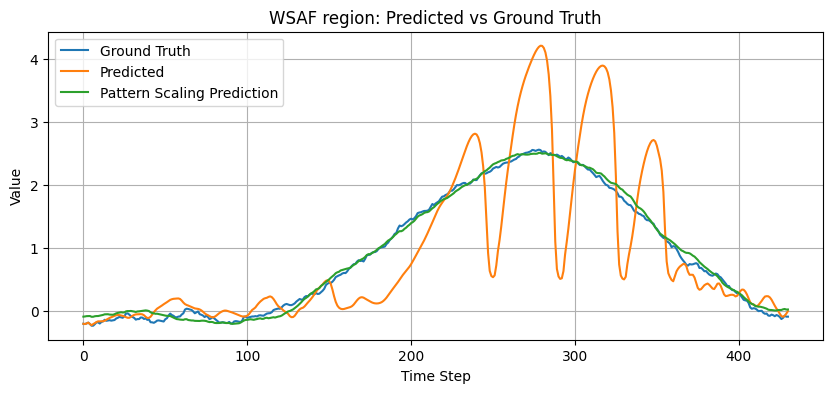

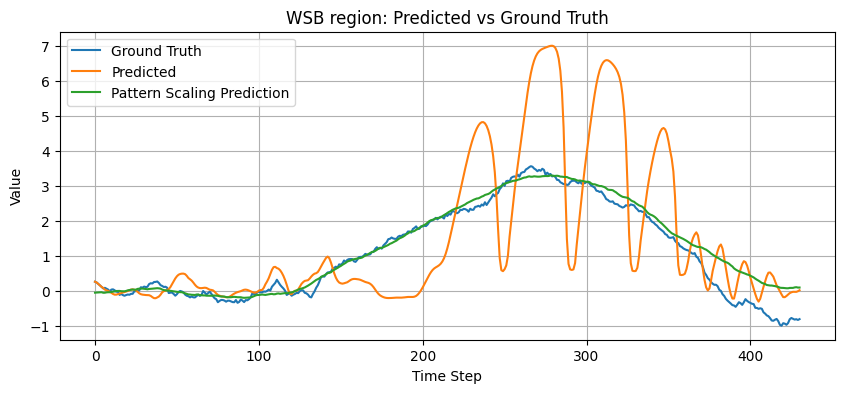

In [18]:
pattern_scaling_prediction = predict_regional_temperatures(gmt_autoregressive_test, regional_regression_slopes_intersepts["slopes_up"], regional_regression_slopes_intersepts["intercepts_up"], regional_regression_slopes_intersepts["slopes_down"], regional_regression_slopes_intersepts["intercepts_down"]).T
pattern_scaling_prediction_no_ramp_down = predict_regional_temperatures(gmt_autoregressive_test, regional_regression_slopes_intersepts["slopes_up"], regional_regression_slopes_intersepts["intercepts_up"], None, None).T

for i in range(num_series):
    plt.figure(figsize=(10, 4))
    
    if PATTERN_SCALING_RESIDUALS:
        plt.plot(range(timesteps),  full_reg_pred_with_spin_off[i], label="Residuals Predicted")
        plt.plot(range(timesteps),autoregressive_test_groudtruth[i], label="Residuals Ground Truth")
        plt.plot(range(timesteps), pattern_scaling_prediction[i,:] - autoregressive_test_groudtruth[i], label="Ground Truth")
        plt.plot(range(timesteps), pattern_scaling_prediction[i,:] - full_reg_pred_with_spin_off[i], label="Predicted")
        plt.plot(range(timesteps), pattern_scaling_prediction[i,:], label="Pattern Scaling Prediction with ramp down correction")
        plt.plot(range(timesteps), pattern_scaling_prediction_no_ramp_down[i,:], label="Pattern Scaling Prediction")
    else:
        plt.plot(range(timesteps), autoregressive_test_groudtruth[i], label="Ground Truth")
        plt.plot(range(timesteps), full_reg_pred_with_spin_off[i], label="Predicted")
        plt.plot(range(timesteps), pattern_scaling_prediction[i,:], label="Pattern Scaling Prediction")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.title(f"{region_names[i]} region: Predicted vs Ground Truth")
    plt.legend()
    plt.grid(True)
    plt.show()

(431, 58)
(431, 58)
(431, 58)
(431, 58)


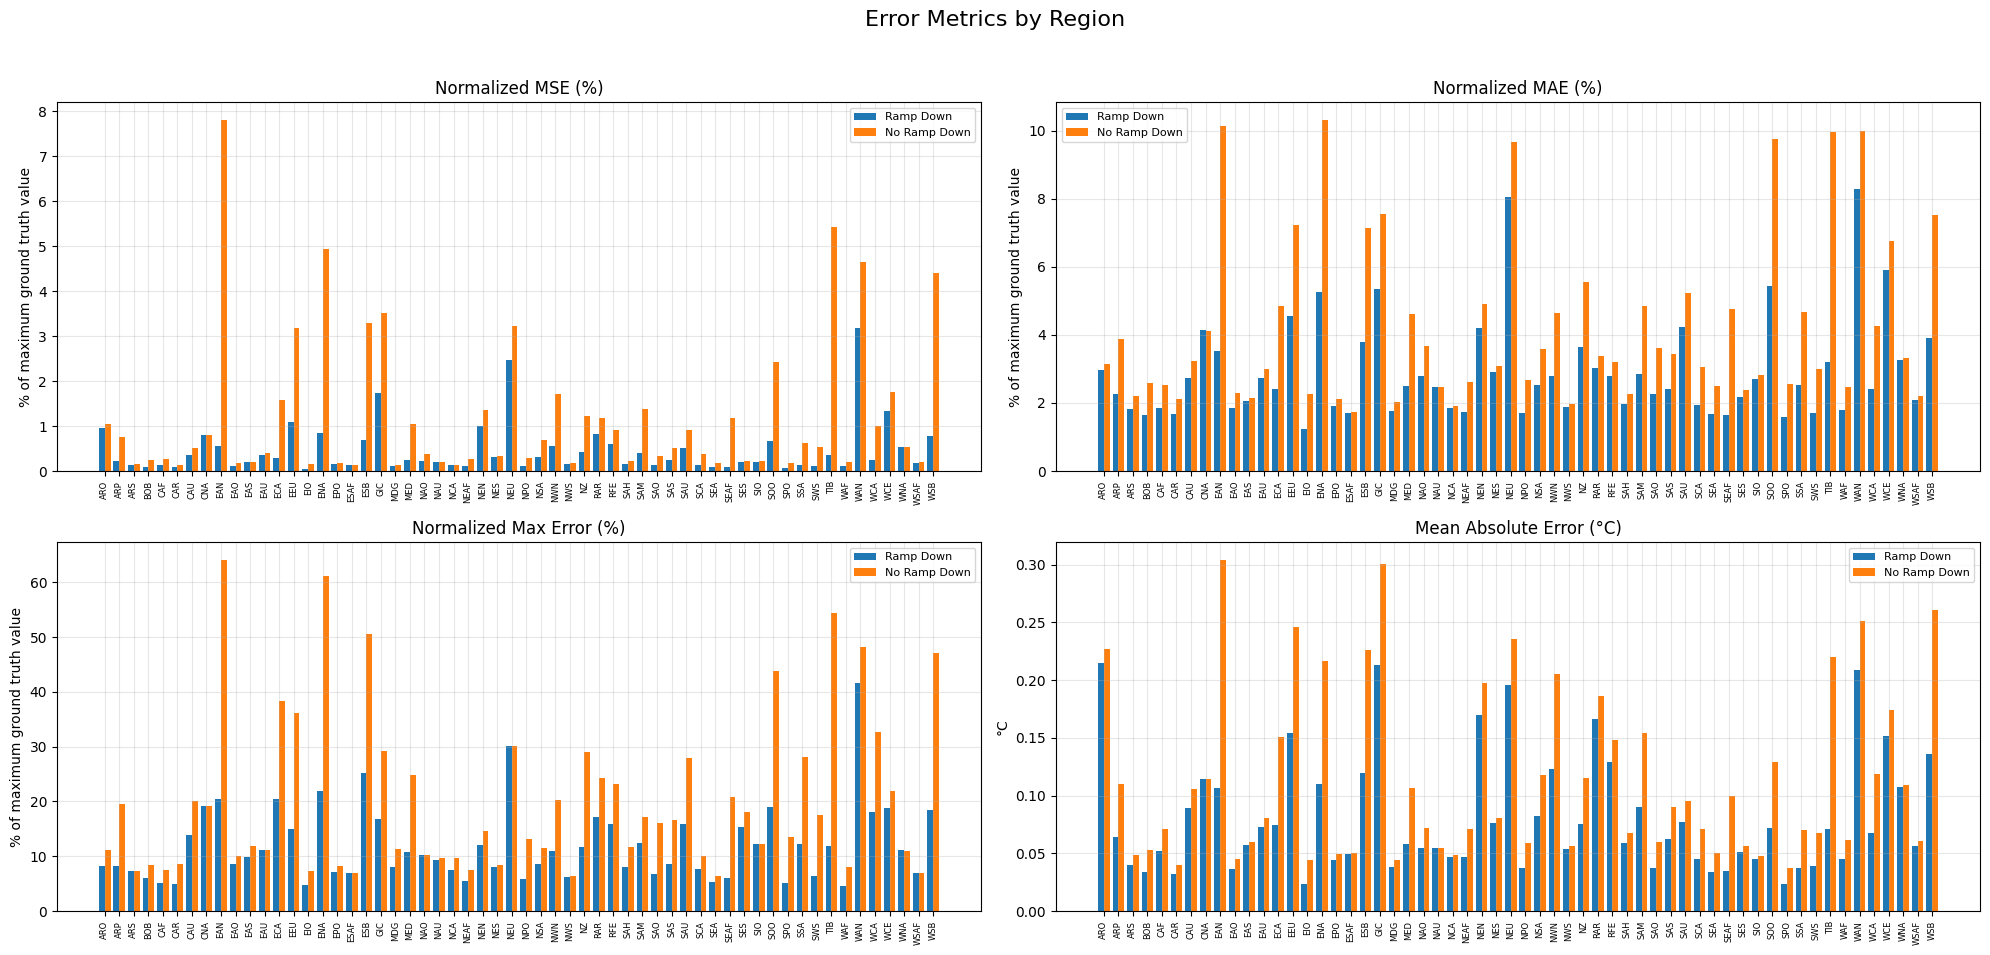

In [38]:
patter_scaling_with_vs_no_rampdown = True

def plot_region_error_metrics(
    pred_list, pred_names, b_real, region_list,
    title="Error Metrics by Region"
):
    """
    Generalized version allowing any number of prediction methods.

    Args:
        pred_list : list of np.ndarray (each N x M) — predicted values
        pred_names : list of str — names of prediction methods (same length as pred_list)
        b_real : np.ndarray (N x M) — real values
        region_list : list of str — region names (length M)
        title : str — plot title
    """

    # --- Input checks ---
    assert len(pred_list) == len(pred_names), "pred_list and pred_names must match in length"
    
    N, M = b_real.shape
    for p in pred_list:
        print(p.shape)
        print(b_real.shape)
        assert p.shape == (N, M), "All predictions must match the shape of b_real"

    assert len(region_list) == M, "region_list length must match number of regions"

    # --- Compute metrics for one prediction ---
    def compute_metrics(b_pred):
        norm_mse, norm_mae, norm_max_err, mae = [], [], [], []
        for i in range(M):
            real = b_real[:, i]
            pred = b_pred[:, i]
            max_real = np.nanmax(real)

            mse = np.nanmean((pred - real)**2)
            mae_val = np.nanmean(np.abs(pred - real))
            max_err_val = np.nanmax(np.abs(pred - real))

            norm_mse.append(100 * mse / max_real)
            norm_mae.append(100 * mae_val / max_real)
            norm_max_err.append(100 * max_err_val / max_real)
            mae.append(mae_val)

        return np.array(norm_mse), np.array(norm_mae), np.array(norm_max_err), np.array(mae)

    # --- Compute for all methods ---
    all_metrics = [compute_metrics(pred) for pred in pred_list]

    metric_names = [
        "Normalized MSE (%)",
        "Normalized MAE (%)",
        "Normalized Max Error (%)",
        "Mean Absolute Error (°C)",
    ]
    y_labels = [
        "% of maximum ground truth value",
        "% of maximum ground truth value",
        "% of maximum ground truth value",
        "°C",
    ]

    # --- Setup figure ---
    fig, axes = plt.subplots(2, 2, figsize=(20, 10))
    fig.suptitle(title, fontsize=16, y=0.95)

    x = np.arange(len(region_list))
    num_methods = len(pred_list)
    width = 0.8 / num_methods   # distribute bars across region

    # --- Loop over metrics (4 panels) ---
    for ax, metric_idx in zip(axes.flatten(), range(4)):
        
        for j, (method_metrics, name) in enumerate(zip(all_metrics, pred_names)):
            data = method_metrics[metric_idx]
            ax.bar(x + (j - num_methods/2) * width + width/2,
                   data, width, label=name)

        ax.set_ylabel(y_labels[metric_idx])
        ax.set_xticks(x)
        ax.set_xticklabels(region_list, rotation=90, fontsize=6)
        ax.set_title(metric_names[metric_idx])
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

if PATTERN_SCALING_RESIDUALS and not patter_scaling_with_vs_no_rampdown:

    plot_region_error_metrics([(pattern_scaling_prediction - full_reg_pred_with_spin_off).transpose(1,0),pattern_scaling_prediction.T], ['XGBoost', 'Pattern Scaling'], (pattern_scaling_prediction - autoregressive_test_groudtruth).transpose(1,0), region_list = [r for r in region_names if r != "GLOBAL"])
elif not patter_scaling_with_vs_no_rampdown:
    plot_region_error_metrics([full_reg_pred_with_spin_off.transpose(1,0),pattern_scaling_prediction], ['XGBoost', 'Pattern Scaling'], autoregressive_test_groudtruth.transpose(1,0), region_list = [r for r in region_names if r != "GLOBAL"])

if patter_scaling_with_vs_no_rampdown: 
    plot_region_error_metrics([pattern_scaling_prediction.T,pattern_scaling_prediction_no_ramp_down.T], ['Ramp Down', 'No Ramp Down'], (pattern_scaling_prediction - autoregressive_test_groudtruth).transpose(1,0), region_list = [r for r in region_names if r != "GLOBAL"])